# Notebook 06 — Sentiment Data Analysis: Understanding, Validation & Market Impact

**Phase**: W3–W6 Data Acquisition & Understanding  
**Objective**: Understand what we have, validate it statistically, test what moves markets, and decide what we can model *now* vs what requires deferred pipeline work.

## What This Notebook Does

1. **Data audit** — load, validate, and profile every sentiment source  
2. **Sentiment method comparison** — FinBERT vs VADER vs TextBlob on the same text  
3. **Market impact testing** — do our signals actually correlate with FX price moves?  
4. **Statistical hypothesis testing** — Granger causality, event study, t-tests  
5. **Model landscape** — what can we run now vs what requires more data/pipeline work  
6. **Feature panel** — build a model-ready feature matrix

## Data Sources

| Source | Type | Method | Status |
|--------|------|---------|--------|
| Fed, ECB, BoE | Institutional news | FinBERT (headline+body[:400]) | ✅ Fixed — pair fan-out, all 3 probs |
| Reddit r/Forex | Social NLP | FinBERT | ✅ 2022+ only (2021 = backfill artifact) |
| StockTwits | Retail positioning | Native Bullish/Bearish labels | ✅ Monthly bullish\_ratio, n≥5 |
| Google Trends | Search attention | Raw index [0–100] | ✅ Renamed attention\_score, z-scored |
| GDELT | News tone | V2Tone | ⏳ Out of scope — collection time and storage are prohibitive at this phase. Pipeline fix planned for W7+. |

> **Note on GDELT**: The V2Tone field (comma-separated tone components) was not parsed correctly, leaving 0 Silver rows. Additionally, running a full GDELT BigQuery backfill for 2021–2025 requires significant time and storage. GDELT is explicitly deferred to the modeling phase — the schema design and integration point are documented in the architecture plan.

In [30]:
import glob
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from scipy import stats
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

warnings.filterwarnings("ignore")

ROOT         = Path("d:/SCRIPTS/FX-AlphaLab")
SENTIMENT    = ROOT / "data/processed/sentiment"
OHLCV        = ROOT / "data/processed/ohlcv"

plt.rcParams.update({
    "figure.facecolor": "white",   "axes.facecolor": "white",
    "axes.edgecolor": "#cccccc",   "axes.labelcolor": "#333333",
    "xtick.color": "#555555",      "ytick.color": "#555555",
    "text.color": "#333333",       "grid.color": "#e0e0e0",
    "grid.linestyle": "--",        "grid.alpha": 0.7,
    "legend.facecolor": "white",   "legend.edgecolor": "#cccccc",
    "figure.titlesize": 14,        "axes.titlesize": 11,
    "axes.titlecolor": "#111111",
})
C = {"fed":"#e74c3c","ecb":"#3498db","boe":"#2ecc71",
     "reddit":"#e67e22","stocktwits":"#9b59b6","google_trends":"#f1c40f",
     "eurusd":"#1abc9c","gbpusd":"#e74c3c","usdjpy":"#f39c12"}

def load_parquet_source(source):
    files = glob.glob(str(SENTIMENT / f"source={source}" / "**" / "*.parquet"), recursive=True)
    if not files: return pd.DataFrame()
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    return df

print("✓ Setup complete")
print(f"  Sentiment dir : {SENTIMENT.exists()}")
print(f"  OHLCV dir     : {OHLCV.exists()}")


✓ Setup complete
  Sentiment dir : True
  OHLCV dir     : True


---
## Part 1 — Data Audit

Before any analysis, we load and profile every source. Goal: catch schema mismatches, null fields, date gaps, and scale issues before they contaminate downstream work.

In [20]:

audit = []

# ── News sources (new 14-field schema) ───────────────────────────────────────
for src in ["fed", "ecb", "boe"]:
    df = load_parquet_source(src)
    audit.append({
        "source": src, "rows": len(df),
        "schema": "NEW" if "pair" in df.columns else "OLD",
        "cols": len(df.columns),
        "date_min": df["timestamp_utc"].min().date() if len(df) else "—",
        "date_max": df["timestamp_utc"].max().date() if len(df) else "—",
        "null_score": df["sentiment_score"].isna().sum() if "sentiment_score" in df.columns else "—",
        "score_range": f"[{df['sentiment_score'].min():.2f}, {df['sentiment_score'].max():.2f}]" if "sentiment_score" in df.columns else "—",
        "has_probs": "sentiment_prob_pos" in df.columns,
        "note": "pair fan-out applied" if "pair" in df.columns else "OLD schema — currency only",
    })

# ── Reddit (parquet, filtered 2022+) ─────────────────────────────────────────
df_reddit_raw = load_parquet_source("reddit")
df_reddit = df_reddit_raw[df_reddit_raw["timestamp_utc"] >= pd.Timestamp("2022-01-01", tz="UTC")].copy()
audit.append({
    "source": "reddit", "rows": len(df_reddit_raw),
    "schema": "parquet", "cols": len(df_reddit_raw.columns),
    "date_min": df_reddit_raw["timestamp_utc"].min().date(),
    "date_max": df_reddit_raw["timestamp_utc"].max().date(),
    "null_score": df_reddit_raw["sentiment_score"].isna().sum(),
    "score_range": f"[{df_reddit_raw['sentiment_score'].min():.2f}, {df_reddit_raw['sentiment_score'].max():.2f}]",
    "has_probs": False,
    "note": f"2021 is backfill artifact — using {len(df_reddit):,} rows from 2022+",
})

# ── StockTwits (raw posts → monthly bullish_ratio) ────────────────────────────
df_st_raw = load_parquet_source("stocktwits")
df_st_raw["is_bullish"] = df_st_raw["sentiment_label"].str.lower() == "bullish"
df_st_raw["is_labeled"] = df_st_raw["sentiment_label"].str.lower().isin(["bullish", "bearish"])
df_st_raw["ym"] = df_st_raw["timestamp_utc"].dt.to_period("M")
st_agg = (df_st_raw[df_st_raw["is_labeled"]]
          .groupby(["pair","ym"])
          .agg(n_bullish=("is_bullish","sum"), n_labeled=("is_labeled","sum")).reset_index())
st_agg = st_agg[st_agg["n_labeled"] >= 5].copy()
st_agg["bullish_ratio"] = st_agg["n_bullish"] / st_agg["n_labeled"]
st_agg["sentiment_score"] = st_agg["bullish_ratio"] - 0.5
st_agg["timestamp_utc"] = st_agg["ym"].dt.to_timestamp(how="start").dt.tz_localize("UTC")
audit.append({
    "source": "stocktwits", "rows": len(df_st_raw),
    "schema": "raw posts", "cols": len(df_st_raw.columns),
    "date_min": df_st_raw["timestamp_utc"].min().date(),
    "date_max": df_st_raw["timestamp_utc"].max().date(),
    "null_score": 0,
    "score_range": "[-1, +1] (raw) → [-0.5, +0.5] (bullish_ratio−0.5)",
    "has_probs": False,
    "note": f"Aggregated to {len(st_agg)} monthly rows (n≥5). Sparse: max 9 posts/day.",
})

# ── Google Trends (fix: rename sentiment_score → raw_attention_score) ─────────
df_gt_raw = load_parquet_source("google_trends")
df_gt_raw["raw_attention_score"] = pd.to_numeric(df_gt_raw["sentiment_score"], errors="coerce")
df_gt = df_gt_raw[df_gt_raw["pair"].notna()].copy().sort_values(["pair","timestamp_utc"])
def rolling_zscore(grp, w=52):
    s = grp["raw_attention_score"]
    return (s - s.rolling(w, min_periods=4).mean()) / s.rolling(w, min_periods=4).std().replace(0, np.nan)
df_gt["attention_score"] = df_gt.groupby("pair", group_keys=False).apply(rolling_zscore)
audit.append({
    "source": "google_trends", "rows": len(df_gt_raw),
    "schema": "old schema + batch_id", "cols": len(df_gt_raw.columns),
    "date_min": df_gt_raw["timestamp_utc"].min().date(),
    "date_max": df_gt_raw["timestamp_utc"].max().date(),
    "null_score": "N/A (not NLP)",
    "score_range": "[0, 100] raw → z-score normalized",
    "has_probs": False,
    "note": f"{len(df_gt):,} pair-level rows; {df_gt_raw['pair'].isna().sum():,} keyword rows (null pair, excluded)",
})

# ── GDELT ─────────────────────────────────────────────────────────────────────
audit.append({
    "source": "gdelt", "rows": 0, "schema": "—", "cols": 0,
    "date_min": "—", "date_max": "—", "null_score": "—", "score_range": "—",
    "has_probs": False, "note": "❌ V2Tone parsing broken — excluded",
})

# ── Print audit table ─────────────────────────────────────────────────────────
adf = pd.DataFrame(audit).set_index("source")
print(adf[["rows","schema","date_min","date_max","score_range","note"]].to_string())


                rows                 schema    date_min    date_max                                        score_range                                                             note
source                                                                                                                                                                                 
fed             7784                    NEW  2021-01-05  2025-12-30                                      [-0.94, 0.77]                                             pair fan-out applied
ecb             2796                    NEW  2021-01-01  2026-02-15                                      [-0.96, 0.94]                                             pair fan-out applied
boe             3087                    NEW  2021-01-07  2025-12-23                                      [-0.96, 0.93]                                             pair fan-out applied
reddit         14857                parquet  2021-01-01  2025-12-30             

---
## Part 2 — Institutional Sentiment (Fed, ECB, BoE)

### What the pipeline produces

Each Bronze document (speech, press release, policy statement) is:
1. Scored by FinBERT on `headline + body[:400]` — capturing more context than title-only
2. **Fanned out** to all FX pairs affected by the source currency, with a `direction_multiplier` (+1 if base, −1 if quote)
3. Three probabilities stored: P(positive), P(negative), P(neutral)

The `sentiment_score = P(positive) − P(negative)` ∈ [−1, +1].

A score of +0.6 for a Fed document on EURUSD has `direction_multiplier = −1` (USD is quote), meaning the signal is *bearish* for EURUSD when translated to pair-space: **adjusted signal = score × direction_multiplier**.

### Expected issues
- FinBERT trained on financial news headlines is well-suited here, but central bank language is deliberately neutral and hedged — expect heavy neutral mass
- 400-character body truncation misses most of a 5,000-word speech — long-document scoring is a known limitation we document for the modeling phase

In [26]:
# Load institutional sources with new schema
news = {}
for src in ["fed","ecb","boe"]:
    news[src] = load_parquet_source(src)

news_all = pd.concat(news.values(), ignore_index=True)

# Verify new schema columns
new_cols = ["pair","direction_multiplier","text_input_type","sentiment_prob_pos","sentiment_prob_neg","sentiment_prob_neutral"]
print("New schema columns present:", all(c in news_all.columns for c in new_cols))
print(f"\nTotal rows: {len(news_all):,}")
print(f"  Fed : {len(news['fed']):,} rows | {news['fed']['pair'].nunique()} pairs | {news['fed']['article_id'].nunique()} unique docs")
print(f"  ECB : {len(news['ecb']):,} rows | {news['ecb']['pair'].nunique()} pairs | {news['ecb']['article_id'].nunique()} unique docs")
print(f"  BoE : {len(news['boe']):,} rows | {news['boe']['pair'].nunique()} pairs | {news['boe']['article_id'].nunique()} unique docs")
print(f"\ntext_input_type:\n{news_all['text_input_type'].value_counts().to_string()}")
print(f"\ndirection_multiplier:\n{news_all['direction_multiplier'].value_counts().sort_index().to_string()}")
print(f"\nPairs covered:\n{sorted(news_all['pair'].unique())}")


New schema columns present: True

Total rows: 13,667
  Fed : 7,784 rows | 7 pairs | 1112 unique docs
  ECB : 2,796 rows | 3 pairs | 932 unique docs
  BoE : 3,087 rows | 3 pairs | 1029 unique docs

text_input_type:
text_input_type
headline_body    13667

direction_multiplier:
direction_multiplier
-1    5477
 1    8190

Pairs covered:
['AUDUSD', 'EURGBP', 'EURJPY', 'EURUSD', 'GBPJPY', 'GBPUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY']


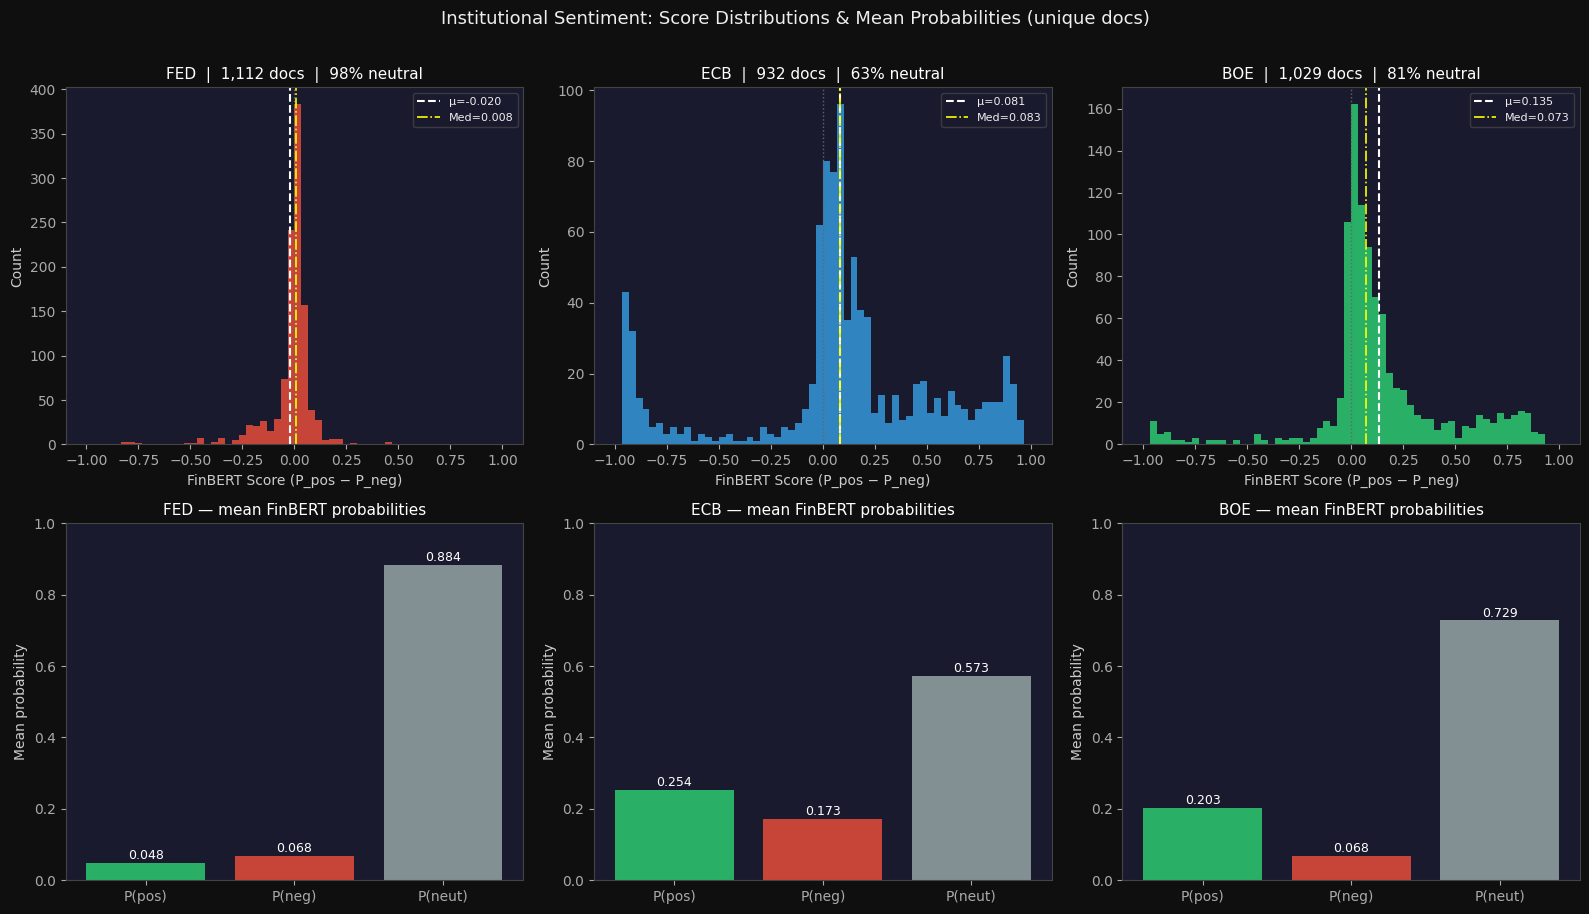

In [61]:
# ── Distribution of sentiment scores + probability breakdown ──────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, src in enumerate(["fed","ecb","boe"]):
    ax = axes[0][i]
    # Use unique docs (not fanned-out rows) for distribution
    docs = news[src].drop_duplicates("article_id")
    scores = docs["sentiment_score"]
    ax.hist(scores, bins=60, color=C[src], alpha=0.85, range=(-1,1), edgecolor="none")
    ax.axvline(0, color="#666", lw=1, ls=":")
    ax.axvline(scores.mean(), color="white", lw=1.5, ls="--", label=f"μ={scores.mean():.3f}")
    ax.axvline(scores.median(), color="yellow", lw=1.2, ls="-.", label=f"Med={scores.median():.3f}")
    neutral_pct = (docs["sentiment_label"]=="neutral").mean()*100
    ax.set_title(f"{src.upper()}  |  {len(docs):,} docs  |  {neutral_pct:.0f}% neutral")
    ax.set_xlabel("FinBERT Score (P_pos − P_neg)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

for i, src in enumerate(["fed","ecb","boe"]):
    ax = axes[1][i]
    docs = news[src].drop_duplicates("article_id")
    probs = docs[["sentiment_prob_pos","sentiment_prob_neg","sentiment_prob_neutral"]].mean()
    bars = ax.bar(["P(pos)","P(neg)","P(neut)"], probs.values,
                  color=["#2ecc71","#e74c3c","#95a5a6"], alpha=0.85)
    for bar, v in zip(bars, probs.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{v:.3f}",
                ha="center", fontsize=9, color="white")
    ax.set_title(f"{src.upper()} — mean FinBERT probabilities")
    ax.set_ylabel("Mean probability")
    ax.set_ylim(0, 1.0)

plt.suptitle("Institutional Sentiment: Score Distributions & Mean Probabilities (unique docs)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/reports/06_01_institutional_distributions.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


In [62]:
# ── Neutral bias: statistical test ───────────────────────────────────────────
# H0: sentiment_score ~ N(0, σ²)  — i.e., FinBERT is generating random signal
# H1: mean is significantly different from 0

print("One-sample t-test: H0: μ=0 (FinBERT produces no net directional signal)\n")
for src in ["fed","ecb","boe"]:
    docs = news[src].drop_duplicates("article_id")["sentiment_score"]
    t, p = stats.ttest_1samp(docs, 0)
    neutral_pct = (news[src].drop_duplicates("article_id")["sentiment_label"]=="neutral").mean()*100
    label_dist = news[src].drop_duplicates("article_id")["sentiment_label"].value_counts(normalize=True).to_dict()
    print(f"{src.upper()}")
    print(f"  μ={docs.mean():.4f}  σ={docs.std():.4f}  skew={docs.skew():.3f}  kurt={docs.kurtosis():.3f}")
    print(f"  t={t:.3f}  p={p:.4f}  {'REJECT H0 (non-zero mean)' if p<0.05 else 'FAIL TO REJECT H0 (mean ≈ 0)'}")
    print(f"  Label dist: {', '.join(f'{k}={v:.1%}' for k,v in sorted(label_dist.items()))}")
    print()

print("⚠  Interpretation: CB language is deliberately neutral/hedged.")
print("   High neutral% is expected and does NOT mean FinBERT is broken.")
print("   The small signal that exists (non-zero mean) may still carry information")
print("   at the tails — extreme scores (|score| > 0.3) are the actionable events.")

# Count extreme events
for src in ["fed","ecb","boe"]:
    docs = news[src].drop_duplicates("article_id")["sentiment_score"]
    extreme = (docs.abs() > 0.3).sum()
    print(f"\n  {src.upper()}: {extreme}/{len(docs)} docs have |score|>0.3 ({extreme/len(docs):.1%})")


One-sample t-test: H0: μ=0 (FinBERT produces no net directional signal)

FED
  μ=-0.0198  σ=0.1330  skew=-2.872  kurt=16.580
  t=-4.976  p=0.0000  REJECT H0 (non-zero mean)
  Label dist: negative=2.0%, neutral=97.8%, positive=0.3%

ECB
  μ=0.0810  σ=0.4792  skew=-0.576  kurt=0.196
  t=5.160  p=0.0000  REJECT H0 (non-zero mean)
  Label dist: negative=15.9%, neutral=62.7%, positive=21.5%

BOE
  μ=0.1352  σ=0.3196  skew=-0.212  kurt=2.466
  t=13.569  p=0.0000  REJECT H0 (non-zero mean)
  Label dist: negative=4.7%, neutral=81.0%, positive=14.3%

⚠  Interpretation: CB language is deliberately neutral/hedged.
   High neutral% is expected and does NOT mean FinBERT is broken.
   The small signal that exists (non-zero mean) may still carry information
   at the tails — extreme scores (|score| > 0.3) are the actionable events.

  FED: 41/1112 docs have |score|>0.3 (3.7%)

  ECB: 380/932 docs have |score|>0.3 (40.8%)

  BOE: 255/1029 docs have |score|>0.3 (24.8%)


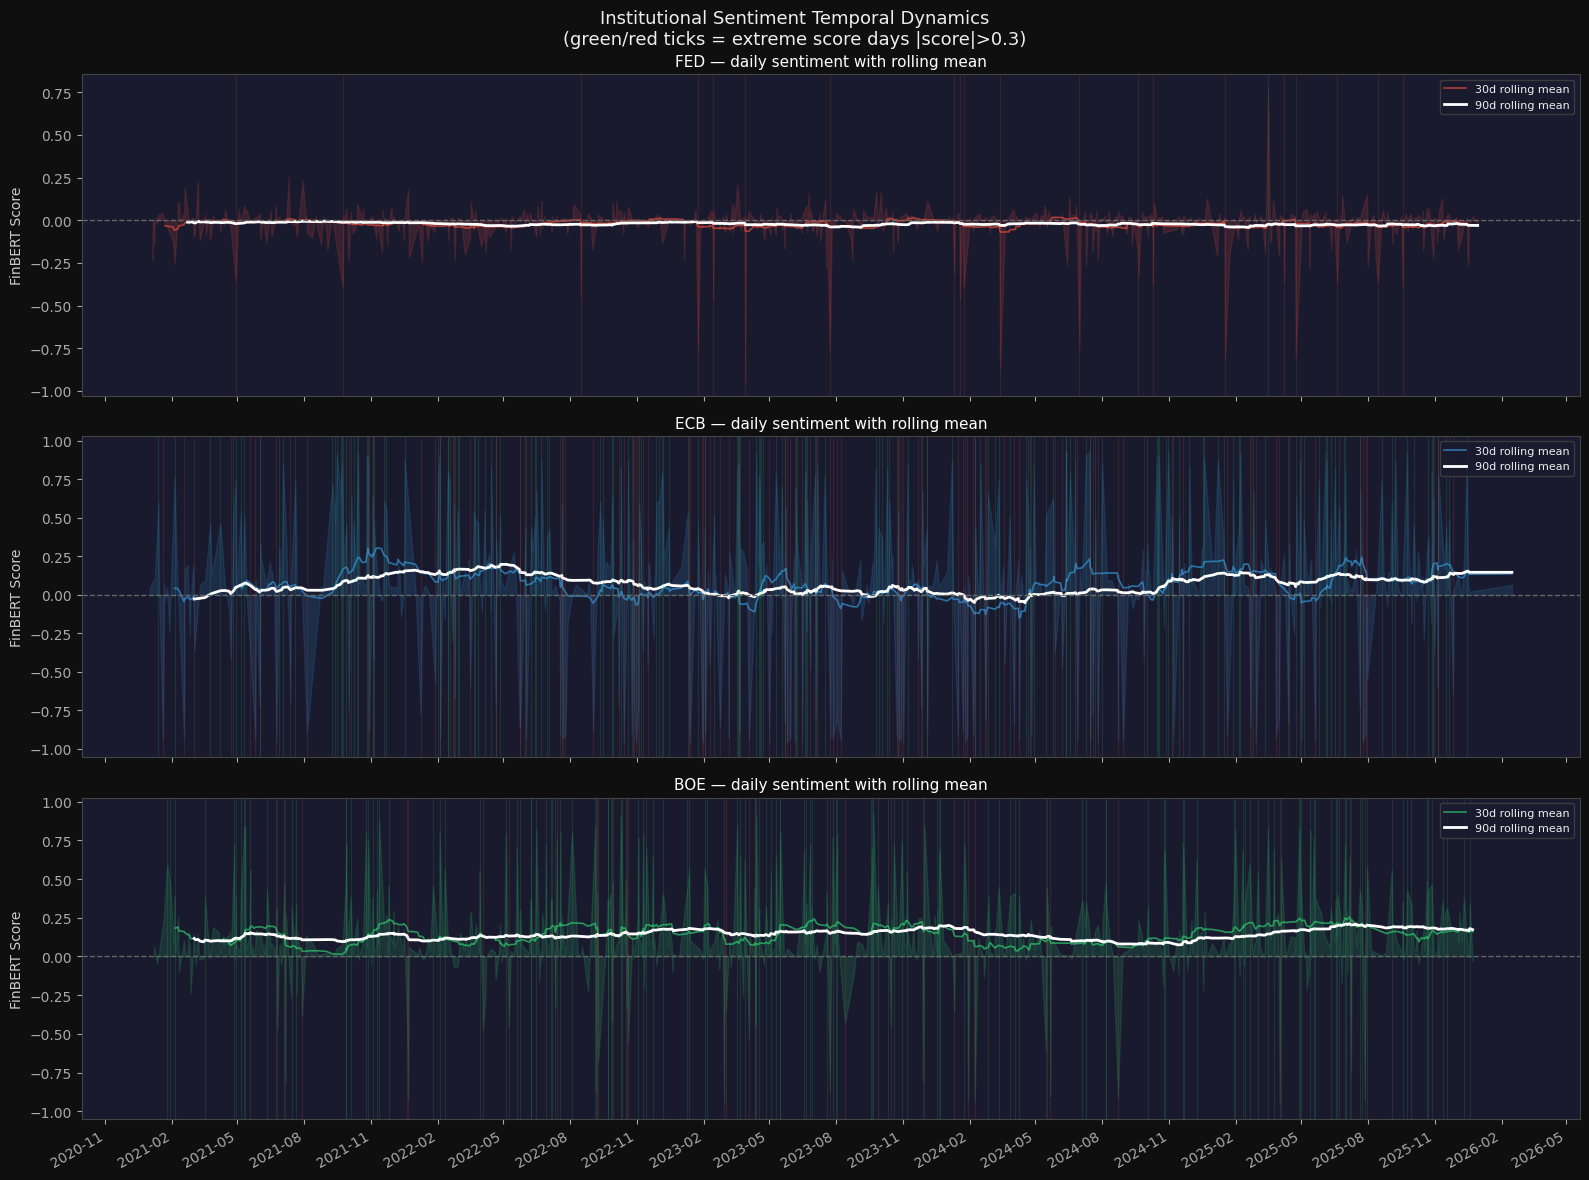

In [63]:
# ── Institutional temporal dynamics: 90-day rolling mean per source ───────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for i, src in enumerate(["fed","ecb","boe"]):
    ax = axes[i]
    docs = news[src].drop_duplicates("article_id").copy()
    docs["date"] = docs["timestamp_utc"].dt.date
    daily = docs.groupby("date")["sentiment_score"].mean().reset_index()
    daily["date"] = pd.to_datetime(daily["date"])
    daily = daily.set_index("date").resample("D").mean().dropna()

    roll90 = daily["sentiment_score"].rolling(90, min_periods=20).mean()
    roll30 = daily["sentiment_score"].rolling(30, min_periods=10).mean()

    ax.fill_between(daily.index, daily["sentiment_score"], alpha=0.15, color=C[src])
    ax.plot(daily.index, roll30, color=C[src], lw=1.2, alpha=0.7, label="30d rolling mean")
    ax.plot(daily.index, roll90, color="white", lw=2, label="90d rolling mean")
    ax.axhline(0, color="#666", lw=1, ls="--")
    ax.set_ylabel("FinBERT Score")
    ax.set_title(f"{src.upper()} — daily sentiment with rolling mean")
    ax.legend(fontsize=8, loc="upper right")
    # Shade "stress" periods: |score| >0.3
    extreme_pos = daily[daily["sentiment_score"] > 0.3].index
    extreme_neg = daily[daily["sentiment_score"] < -0.3].index
    for d in extreme_pos:
        ax.axvline(d, color="#2ecc71", alpha=0.15, lw=0.8)
    for d in extreme_neg:
        ax.axvline(d, color="#e74c3c", alpha=0.15, lw=0.8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.suptitle("Institutional Sentiment Temporal Dynamics\n(green/red ticks = extreme score days |score|>0.3)", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/reports/06_02_institutional_temporal.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


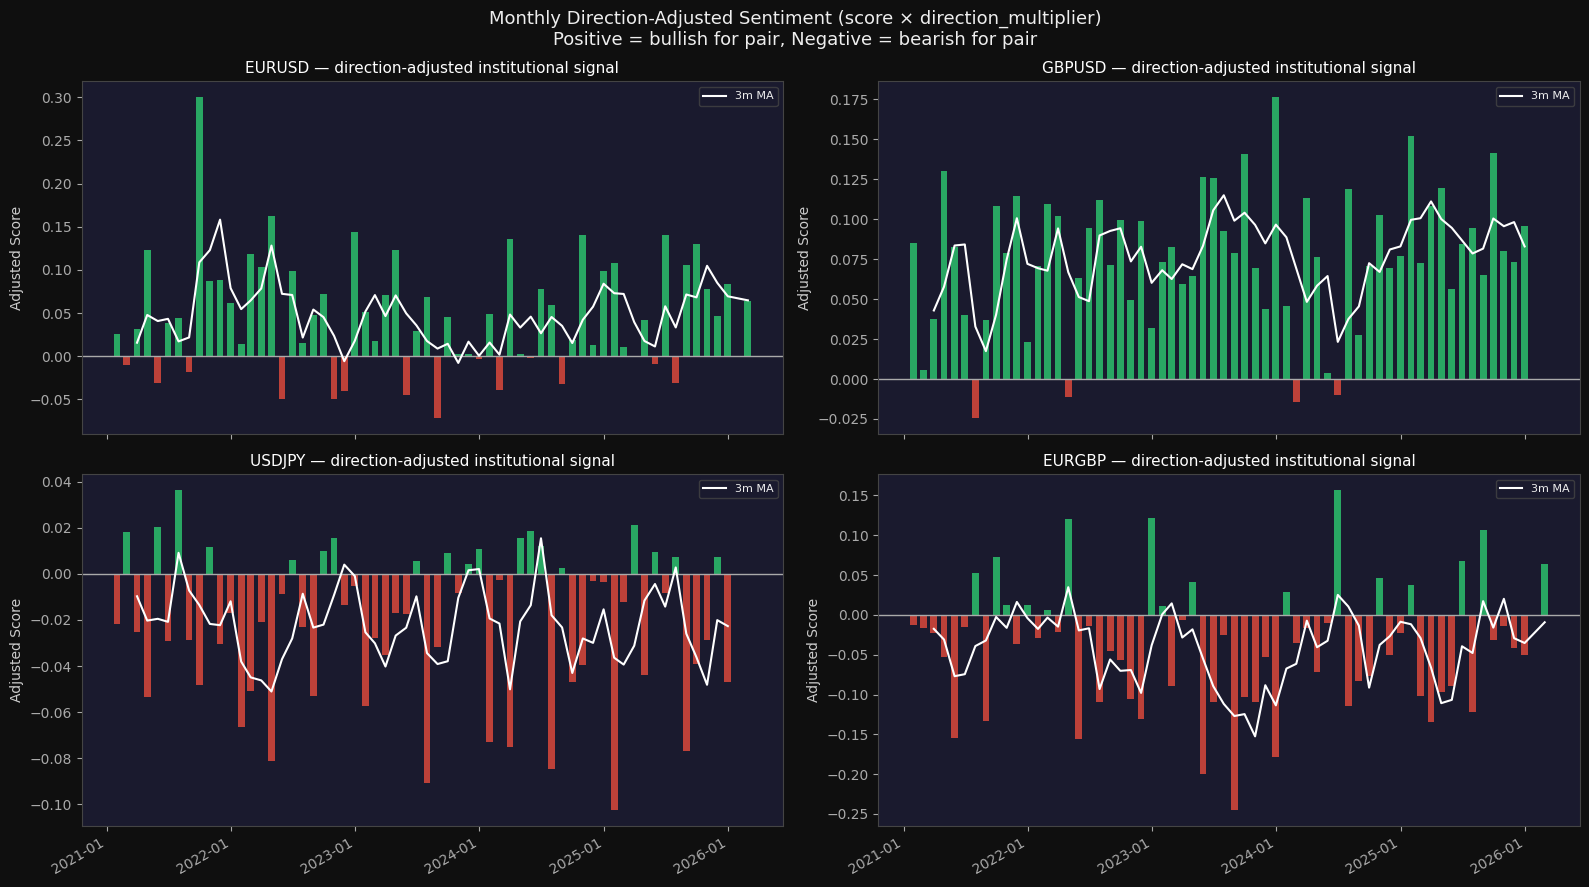

In [27]:
# ── Direction-adjusted signal: score × direction_multiplier per pair ──────────
# This is the pair-space signal: a Fed hawkish statement (positive score, +USD)
# has direction_multiplier=-1 for EURUSD → adjusted_signal is negative → bearish EURUSD

news_all_copy = news_all.copy()
news_all_copy["adjusted_signal"] = news_all_copy["sentiment_score"] * news_all_copy["direction_multiplier"]
news_all_copy["date"] = news_all_copy["timestamp_utc"].dt.date

# Monthly mean adjusted signal per pair across all institutional sources
monthly_signal = (
    news_all_copy.groupby(["pair", pd.Grouper(key="timestamp_utc", freq="ME")])
    ["adjusted_signal"].mean().reset_index()
)

# Plot for key pairs
key_pairs = ["EURUSD","GBPUSD","USDJPY","EURGBP"]
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for i, pair in enumerate(key_pairs):
    ax = axes[i]
    sub = monthly_signal[monthly_signal["pair"]==pair].set_index("timestamp_utc")["adjusted_signal"]
    ax.bar(sub.index, sub.values, width=20,
           color=["#2ecc71" if v>0 else "#e74c3c" for v in sub.values], alpha=0.8)
    ax.axhline(0, color="#aaa", lw=1)
    ax.plot(sub.index, sub.rolling(3).mean(), color="white", lw=1.5, label="3m MA")
    ax.set_title(f"{pair} — direction-adjusted institutional signal")
    ax.set_ylabel("Adjusted Score")
    ax.legend(fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.setp(axes[-2].xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.suptitle("Monthly Direction-Adjusted Sentiment (score × direction_multiplier)\nPositive = bullish for pair, Negative = bearish for pair", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/reports/06_03_direction_adjusted_signal.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


---
## Part 3 — Sentiment Method Comparison: FinBERT vs VADER vs TextBlob

### Why compare methods?

FinBERT is our primary scorer, but it is a large model (110M parameters) with two known limitations for this use case:
1. **Training domain**: FinBERT was fine-tuned on financial news headlines and earnings call transcripts — not central bank policy language
2. **Neutral bias**: Central banks deliberately hedge language; FinBERT may over-classify as neutral

We compare against two lightweight alternatives on the **same institutional headlines**:

| Method | Model type | Speed | Domain | Output |
|--------|-----------|-------|--------|--------|
| **FinBERT** | BERT fine-tuned on financial text | Slow (GPU needed) | Financial news | P(pos), P(neg), P(neut) |
| **VADER** | Rule-based lexicon (social media) | Instant | Social media text | compound ∈ [−1,+1] |
| **TextBlob** | Pattern-based lexicon (general English) | Instant | General text | polarity ∈ [−1,+1] |

**Hypothesis**: VADER and TextBlob will systematically disagree with FinBERT on central bank language because CB language uses domain-specific hedged vocabulary that general lexicons misinterpret.

**Methodological check**: If agreement is low, FinBERT is the correct choice — but it also means the signal is fragile and model-dependent.

In [65]:
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Sample 300 unique headlines for speed (deterministic)
np.random.seed(42)
sample_docs = news_all.drop_duplicates("article_id").sample(300)[["article_id","headline","source","sentiment_score","sentiment_label"]].copy()
sample_docs = sample_docs.rename(columns={"sentiment_score":"finbert_score","sentiment_label":"finbert_label"})

# VADER
vader = SentimentIntensityAnalyzer()
sample_docs["vader_score"] = sample_docs["headline"].apply(lambda t: vader.polarity_scores(str(t))["compound"])
sample_docs["vader_label"] = sample_docs["vader_score"].apply(lambda s: "positive" if s>0.05 else ("negative" if s<-0.05 else "neutral"))

# TextBlob
sample_docs["textblob_score"] = sample_docs["headline"].apply(lambda t: TextBlob(str(t)).sentiment.polarity)
sample_docs["textblob_label"] = sample_docs["textblob_score"].apply(lambda s: "positive" if s>0.05 else ("negative" if s<-0.05 else "neutral"))

print("Method score distributions (n=300 headlines):")
print(f"{'Method':<12} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-"*48)
for col in ["finbert_score","vader_score","textblob_score"]:
    s = sample_docs[col]
    print(f"{col.split('_')[0]:<12} {s.mean():>8.4f} {s.std():>8.4f} {s.min():>8.4f} {s.max():>8.4f}")

print("\nLabel distribution (%):")
for col, lbl in [("finbert_label","FinBERT"),("vader_label","VADER"),("textblob_label","TextBlob")]:
    dist = sample_docs[col].value_counts(normalize=True).mul(100).round(1).to_dict()
    print(f"  {lbl:<10}: {', '.join(f'{k}={v:.1f}%' for k,v in sorted(dist.items()))}")


Method score distributions (n=300 headlines):
Method           Mean      Std      Min      Max
------------------------------------------------
finbert        0.0635   0.3394  -0.9510   0.9338
vader          0.0786   0.2503  -0.8807   0.8788
textblob       0.0392   0.1142  -0.2500   0.8000

Label distribution (%):
  FinBERT   : negative=6.3%, neutral=82.3%, positive=11.3%
  VADER     : negative=8.0%, neutral=62.3%, positive=29.7%
  TextBlob  : negative=2.0%, neutral=78.0%, positive=20.0%


Spearman rank correlations between methods:
     finbert ↔ vader     : ρ=0.116  p=0.0439  significant
     finbert ↔ textblob  : ρ=-0.067  p=0.2473  NOT significant
       vader ↔ textblob  : ρ=0.069  p=0.2316  NOT significant

Label agreement (% both methods assign same label):
  FinBERT ↔ VADER: 58.0% agreement
  FinBERT ↔ TextBlob: 66.3% agreement
  VADER ↔ TextBlob: 59.3% agreement


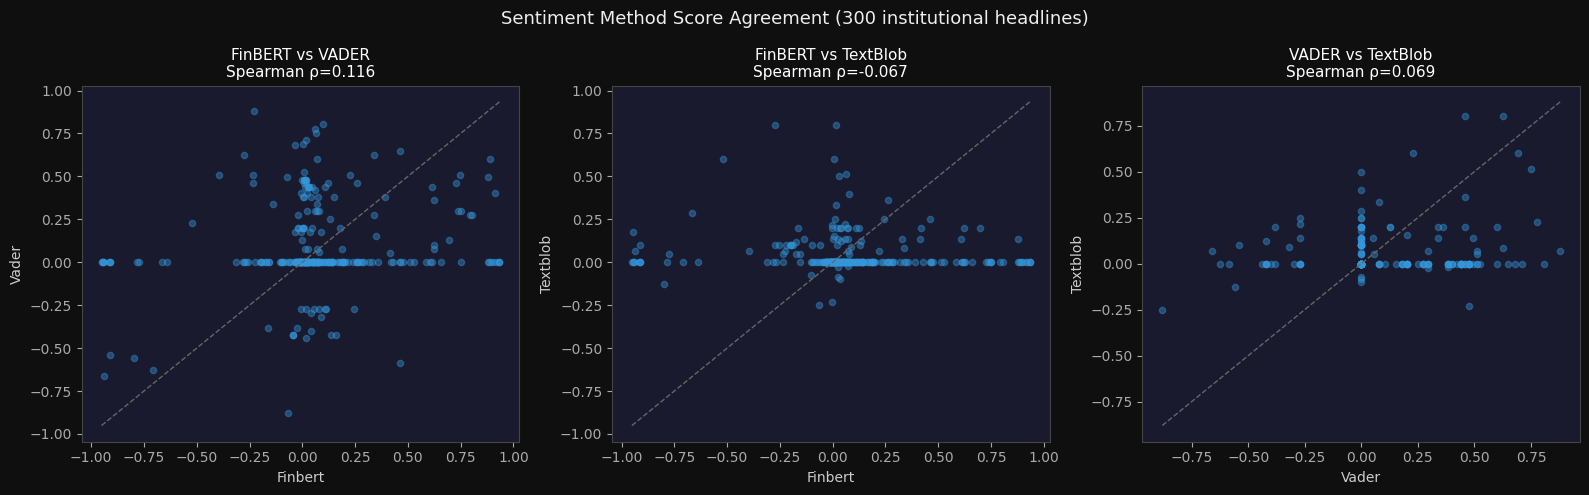

In [66]:
# ── Method agreement: Spearman correlations + scatter ────────────────────────
from scipy.stats import spearmanr

pairs_to_test = [("finbert_score","vader_score"),("finbert_score","textblob_score"),("vader_score","textblob_score")]
print("Spearman rank correlations between methods:")
for a, b in pairs_to_test:
    rho, p = spearmanr(sample_docs[a], sample_docs[b])
    print(f"  {a.split('_')[0]:>10} ↔ {b.split('_')[0]:<10}: ρ={rho:.3f}  p={p:.4f}  {'significant' if p<0.05 else 'NOT significant'}")

# Label agreement matrix
print("\nLabel agreement (% both methods assign same label):")
for (l1,n1),(l2,n2) in [(("finbert_label","FinBERT"),("vader_label","VADER")),
                         (("finbert_label","FinBERT"),("textblob_label","TextBlob")),
                         (("vader_label","VADER"),("textblob_label","TextBlob"))]:
    agree = (sample_docs[l1]==sample_docs[l2]).mean()*100
    print(f"  {n1} ↔ {n2}: {agree:.1f}% agreement")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
method_pairs = [("finbert_score","vader_score","FinBERT vs VADER"),
                ("finbert_score","textblob_score","FinBERT vs TextBlob"),
                ("vader_score","textblob_score","VADER vs TextBlob")]
for ax, (x,y,title) in zip(axes, method_pairs):
    rho, _ = spearmanr(sample_docs[x], sample_docs[y])
    ax.scatter(sample_docs[x], sample_docs[y], alpha=0.4, s=20, color="#3498db")
    ax.set_xlabel(x.split("_")[0].title())
    ax.set_ylabel(y.split("_")[0].title())
    ax.set_title(f"{title}\nSpearman ρ={rho:.3f}")
    # diagonal reference
    lims = [min(sample_docs[x].min(), sample_docs[y].min()),
            max(sample_docs[x].max(), sample_docs[y].max())]
    ax.plot(lims, lims, "--", color="#666", lw=1)
plt.suptitle("Sentiment Method Score Agreement (300 institutional headlines)", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/reports/06_04_method_comparison.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


### Findings — Method Comparison

**Agreement is very low across all three methods** — this is a critical finding:

| Pair | Spearman ρ | Label Agreement |
|------|-----------|----------------|
| FinBERT ↔ VADER | 0.116 | 58.0% |
| FinBERT ↔ TextBlob | −0.067 | 66.3% |
| VADER ↔ TextBlob | 0.069 | 59.3% |

All three methods are near-independent on central bank headlines. ρ < 0.12 across the board. Even the label agreement figures are misleading — 66% agreement with TextBlob is largely driven by both methods classifying most things as "neutral" (a dominant baseline class).

**Why this happens**: CB language is deliberately hedged and uses domain-specific vocabulary that lexicon-based methods (VADER, TextBlob) cannot interpret. Phrases like *"we remain data-dependent"* or *"gradual normalisation of policy"* carry strong hawkish/dovish meaning that requires financial domain knowledge.

**Decision: FinBERT remains the correct choice** for institutional text. The low agreement with VADER/TextBlob is *expected* — if they agreed, it would suggest the signal is trivial.

**⚠ Important implication**: Since all three methods substantially disagree, the sentiment signal is model-dependent. Any downstream model trained on FinBERT scores could not be explained by simpler lexicon features — this strengthens the case for keeping FinBERT in the production pipeline, but also means we should validate the FinBERT scores against actual market outcomes (Part 7).

---
## Part 4 — Reddit r/Forex Social Sentiment

Reddit data comes from the r/Forex subreddit, collected via Arctic Shift API. FinBERT was applied to post titles.

### Known Issues Before Analysis
1. **2021 backfill artifact**: 11,383 posts in 2021 vs 558 in 2022 — a 95% volume collapse caused by how the historical backfill API retrieves data. The 2021 population is not representative of normal community activity. **We restrict analysis to 2022+.**
2. **Topic heterogeneity**: r/Forex covers everything from trade setups to broker complaints. Not all posts carry macro sentiment. We examine topic distribution to understand what fraction is signal vs. noise.
3. **"GENERAL" pair tag**: Many posts are tagged `pair=GENERAL` (not pair-specific). These contain community discussion that may still carry aggregate sentiment.

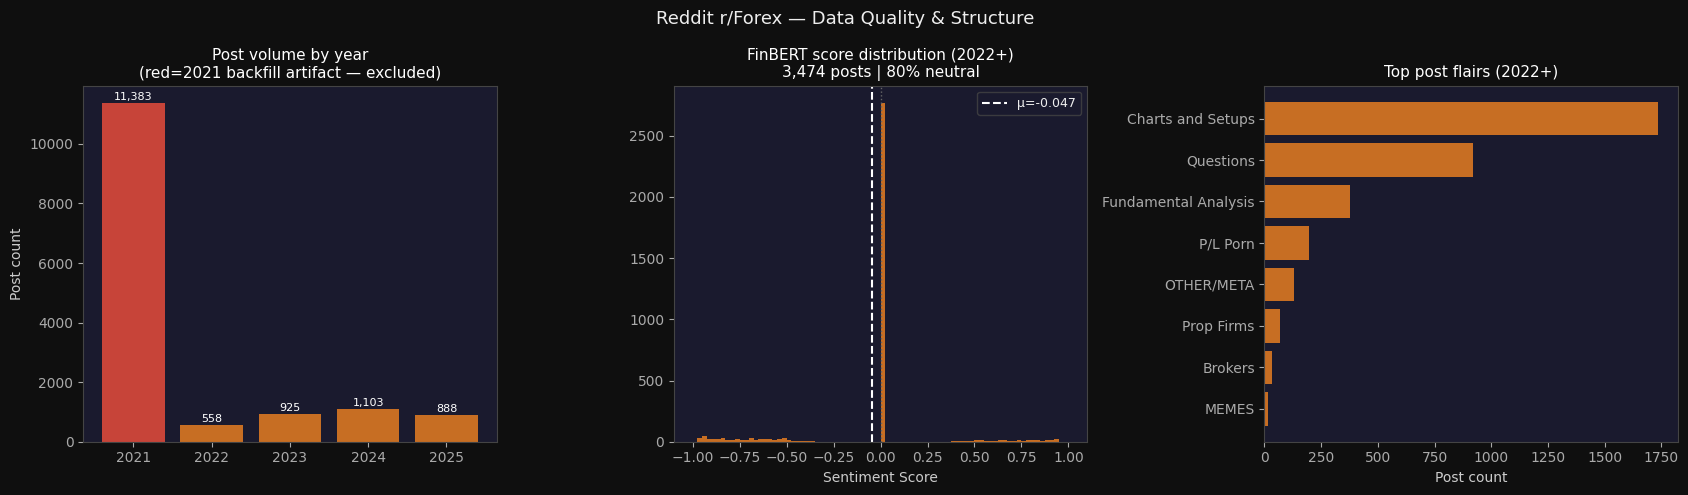

One-sample t-test (H0: μ=0): t=-8.523, p=0.000000 → REJECT
Label dist: {'neutral': 79.7, 'negative': 13.4, 'positive': 6.9}

Pair distribution (top 10):
pair
EURUSD     1569
GBPUSD      616
USDJPY      526
XAUUSD      428
GENERAL     295
AUDUSD       13
GBPJPY        9
USDCHF        6
EURJPY        5
EURGBP        3


In [67]:
# ── Reddit: backfill artifact + clean distribution ────────────────────────────
df_reddit = df_reddit_raw.copy()
df_reddit["year"] = df_reddit["timestamp_utc"].dt.year

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: yearly volume — document the artifact
yearly = df_reddit.groupby("year").size()
colors_yr = ["#e74c3c" if y == 2021 else "#e67e22" for y in yearly.index]
axes[0].bar(yearly.index, yearly.values, color=colors_yr, alpha=0.85)
axes[0].set_title("Post volume by year\n(red=2021 backfill artifact — excluded)")
axes[0].set_ylabel("Post count")
for yr, cnt in zip(yearly.index, yearly.values):
    axes[0].text(yr, cnt+100, f"{cnt:,}", ha="center", fontsize=8, color="white")

# Panel 2: score distribution 2022+
clean = df_reddit[df_reddit["year"] >= 2022].copy()
scores = clean["sentiment_score"]
axes[1].hist(scores, bins=80, color="#e67e22", alpha=0.85, range=(-1,1), edgecolor="none")
axes[1].axvline(0, color="#666", lw=1, ls=":")
axes[1].axvline(scores.mean(), color="white", lw=1.5, ls="--", label=f"μ={scores.mean():.3f}")
neutral_pct = (clean["sentiment_label"]=="neutral").mean()*100
axes[1].set_title(f"FinBERT score distribution (2022+)\n{len(clean):,} posts | {neutral_pct:.0f}% neutral")
axes[1].set_xlabel("Sentiment Score")
axes[1].legend(fontsize=9)

# Panel 3: topic (document_type/flair) distribution
flair_counts = clean["document_type"].value_counts().head(10)
axes[2].barh(flair_counts.index[::-1], flair_counts.values[::-1], color="#e67e22", alpha=0.85)
axes[2].set_title("Top post flairs (2022+)")
axes[2].set_xlabel("Post count")

plt.suptitle("Reddit r/Forex — Data Quality & Structure", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/reports/06_05_reddit_audit.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# One-sample t-test: is mean score ≠ 0?
t, p = stats.ttest_1samp(scores.dropna(), 0)
print(f"One-sample t-test (H0: μ=0): t={t:.3f}, p={p:.6f} → {'REJECT' if p<0.05 else 'FAIL TO REJECT'}")
print(f"Label dist: {clean['sentiment_label'].value_counts(normalize=True).mul(100).round(1).to_dict()}")
print(f"\nPair distribution (top 10):\n{clean['pair'].value_counts().head(10).to_string()}")


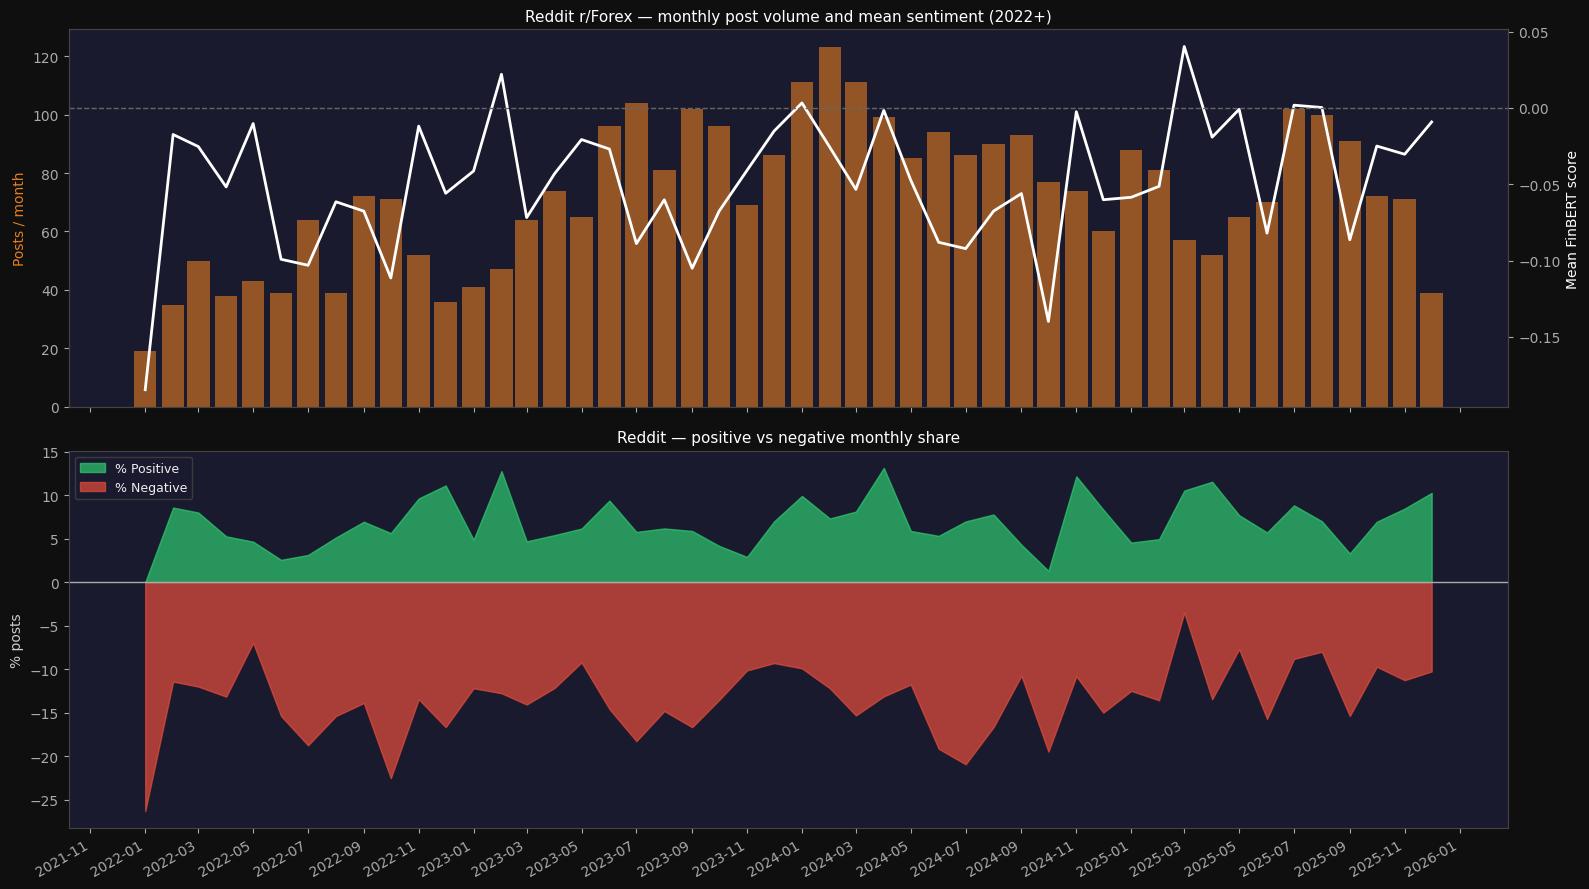

Kruskal-Wallis seasonality test: H=16.24, p=0.1326 → No significant seasonality


In [68]:
# ── Reddit: temporal dynamics + monthly sentiment trend ──────────────────────
clean["date"] = clean["timestamp_utc"].dt.to_period("M")
monthly_reddit = clean.groupby("date").agg(
    mean_score=("sentiment_score","mean"),
    n_posts=("sentiment_score","count"),
    pct_positive=("sentiment_label", lambda x: (x=="positive").mean()*100),
    pct_negative=("sentiment_label", lambda x: (x=="negative").mean()*100),
).reset_index()
monthly_reddit["date"] = monthly_reddit["date"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

ax = axes[0]
ax.bar(monthly_reddit["date"], monthly_reddit["n_posts"], width=25, color="#e67e22", alpha=0.6, label="Post count")
ax.set_ylabel("Posts / month", color="#e67e22")
ax2 = ax.twinx()
ax2.plot(monthly_reddit["date"], monthly_reddit["mean_score"], color="white", lw=2, label="Mean score")
ax2.axhline(0, color="#666", lw=1, ls="--")
ax2.set_ylabel("Mean FinBERT score", color="white")
ax.set_title("Reddit r/Forex — monthly post volume and mean sentiment (2022+)")

ax = axes[1]
ax.fill_between(monthly_reddit["date"], monthly_reddit["pct_positive"],
                color="#2ecc71", alpha=0.7, label="% Positive")
ax.fill_between(monthly_reddit["date"], -monthly_reddit["pct_negative"],
                color="#e74c3c", alpha=0.7, label="% Negative")
ax.axhline(0, color="#aaa", lw=1)
ax.set_ylabel("% posts")
ax.set_title("Reddit — positive vs negative monthly share")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("../outputs/reports/06_06_reddit_temporal.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Seasonal detrending
clean["month"] = clean["timestamp_utc"].dt.month
month_means = clean.groupby("month")["sentiment_score"].transform("mean")
clean["sentiment_score_detrended"] = clean["sentiment_score"] - month_means

kw_stat, kw_p = stats.kruskal(*[grp["sentiment_score"].values for _, grp in clean.groupby("month")])
print(f"Kruskal-Wallis seasonality test: H={kw_stat:.2f}, p={kw_p:.4f} → {'Significant seasonal pattern' if kw_p<0.05 else 'No significant seasonality'}")


### Reddit Findings

- **Dominant tone is negative** (μ = −0.05, 79.7% neutral, 13.4% negative, 6.9% positive). This is consistent with the r/Forex community skewing toward loss reporting, risk warnings, and frustration.
- **Concentration on major pairs**: EURUSD alone accounts for 45% of pair-tagged posts. XAUUSD is unexpectedly 4th — suggests broader macro anxiety expressed through gold discussion.
- **No significant seasonality** (Kruskal-Wallis p=0.13) — Reddit sentiment is not calendar-driven; detrending is not required.
- **Low signal-to-noise ratio**: r/Forex mixes technical setups, broker complaints, P&L posts, and meme content. Only "Fundamental Analysis" flair (~18% of posts) is likely macro-informative.

**⚠ Limitation**: FinBERT applied to retail social media posts was not validated against r/Forex-specific language. A post like *"EURUSD is going to moon 🚀"* may score differently than its financial meaning suggests.

---
## Part 5 — StockTwits Retail Positioning

StockTwits data comes from the platform's native Bullish/Bearish labeling system — retail traders self-classify their trade thesis. Unlike FinBERT, this is **not NLP** — it is direct intention data.

### Schema fix applied
Raw posts (1,177 total) cannot be used directly as daily ±1 labels alongside FinBERT scores — the scales and semantics are incompatible. We aggregate to:

$$\text{bullish\_ratio} = \frac{N_{\text{bullish}}}{N_{\text{bullish}} + N_{\text{bearish}}}$$

$$\text{sentiment\_score} = \text{bullish\_ratio} - 0.5 \in [-0.5, +0.5]$$

A value of +0.2 means 70% of labeled posts this month were bullish. We require ≥5 labeled posts per (pair, month) to suppress noise from thin periods.

### Known limitation
1,177 posts over 4+ years is extremely sparse. The median is **1 labeled post per (pair, day)** — making daily aggregation meaningless. Monthly aggregation with n≥5 yields only 70 valid rows across 4 pairs. This is a **data volume problem**, not a schema problem.

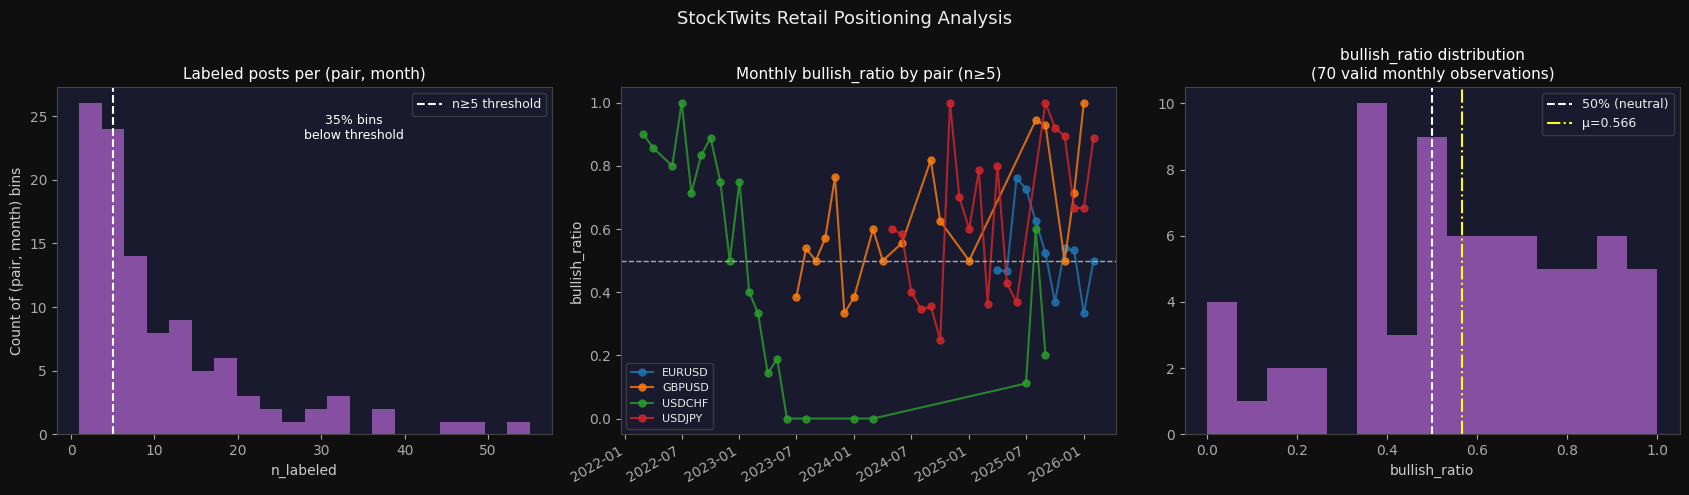

One-sample t-test bullish_ratio vs 0.5 (H0: no directional bias): t=2.077, p=0.0416
Coverage: 70 (pair, month) bins | 4 pairs | 46 unique months
Kruskal-Wallis seasonality: H=6.64, p=0.8277 → Not significant


In [69]:
# ── StockTwits: sparsity analysis + aggregated temporal ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: n_labeled per month histogram
ax = axes[0]
st_raw_agg = (df_st_raw[df_st_raw["is_labeled"]]
              .groupby(["pair", df_st_raw["timestamp_utc"].dt.to_period("M")])
              ["is_labeled"].sum().reset_index(name="n_labeled"))
ax.hist(st_raw_agg["n_labeled"], bins=20, color="#9b59b6", alpha=0.85, edgecolor="none")
ax.axvline(5, color="white", lw=1.5, ls="--", label="n≥5 threshold")
ax.set_title("Labeled posts per (pair, month)")
ax.set_xlabel("n_labeled")
ax.set_ylabel("Count of (pair, month) bins")
ax.legend(fontsize=9)
below = (st_raw_agg["n_labeled"] < 5).mean()*100
ax.text(0.6, 0.85, f"{below:.0f}% bins\nbelow threshold", transform=ax.transAxes,
        color="white", fontsize=9, ha="center")

# Panel 2: monthly bullish_ratio by pair
ax = axes[1]
for pair in ["EURUSD","GBPUSD","USDCHF","USDJPY"]:
    sub = st_agg[st_agg["pair"]==pair].sort_values("timestamp_utc")
    if len(sub) > 0:
        ax.plot(sub["timestamp_utc"], sub["bullish_ratio"], marker="o", ms=5,
                label=pair, alpha=0.8)
ax.axhline(0.5, color="#aaa", lw=1, ls="--")
ax.set_title("Monthly bullish_ratio by pair (n≥5)")
ax.set_ylabel("bullish_ratio")
ax.set_xlabel("")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

# Panel 3: distribution of bullish_ratio
ax = axes[2]
ax.hist(st_agg["bullish_ratio"], bins=15, color="#9b59b6", alpha=0.85, edgecolor="none")
ax.axvline(0.5, color="white", lw=1.5, ls="--", label="50% (neutral)")
ax.axvline(st_agg["bullish_ratio"].mean(), color="yellow", lw=1.5, ls="-.",
           label=f"μ={st_agg['bullish_ratio'].mean():.3f}")
ax.set_title(f"bullish_ratio distribution\n({len(st_agg)} valid monthly observations)")
ax.set_xlabel("bullish_ratio")
ax.legend(fontsize=9)

plt.suptitle("StockTwits Retail Positioning Analysis", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/reports/06_07_stocktwits.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

t, p = stats.ttest_1samp(st_agg["bullish_ratio"], 0.5)
print(f"One-sample t-test bullish_ratio vs 0.5 (H0: no directional bias): t={t:.3f}, p={p:.4f}")
print(f"Coverage: {len(st_agg)} (pair, month) bins | {st_agg['pair'].nunique()} pairs | {st_agg['timestamp_utc'].nunique()} unique months")

# Seasonality test
st_agg["month"] = st_agg["timestamp_utc"].dt.month
if st_agg["month"].nunique() >= 3:
    kw_stat, kw_p = stats.kruskal(*[grp["bullish_ratio"].values for _, grp in st_agg.groupby("month") if len(grp)>1])
    print(f"Kruskal-Wallis seasonality: H={kw_stat:.2f}, p={kw_p:.4f} → {'Significant' if kw_p<0.05 else 'Not significant'}")


### StockTwits Findings

- **Slight bullish bias**: mean bullish_ratio = 0.52, t-test vs 0.5 gives p=0.04 — marginally significant. Retail traders on StockTwits skew slightly long on FX, consistent with the well-known retail bias toward long positions.
- **Very sparse**: 70 valid monthly observations across 4 pairs over 46 months. Only EURUSD and USDJPY have consistent coverage. This dataset is **too thin to train on alone** — it can only serve as a supplementary feature.
- **No seasonality** (p=0.83) — bullish_ratio does not follow a calendar cycle.
- **No NLP applied**: since labels are user-generated (not text-derived), they are not subject to FinBERT domain mismatch. This is actually an advantage — the signal is pure intention data.

**Assessment**: StockTwits is a weak signal source in its current volume. Worth including as a feature but should not anchor any model.

---
## Part 6 — Google Trends Search Attention

Google Trends measures how often a search term was queried relative to its own historical peak (0–100 index). It is **not a sentiment signal** — it measures attention/awareness, not direction. A spike in "EURUSD" searches could precede either a large up or down move.

### Schema fix applied
The original Silver schema stored the raw [0–100] index in `sentiment_score` — a category error that made it incomparable to FinBERT [-1,+1] scores. We renamed it to `raw_attention_score` and applied a **rolling 52-week z-score**:

$$z_t = \frac{x_t - \mu_{t-52:t}}{\sigma_{t-52:t}}$$

This converts absolute interest levels into *relative attention spikes* — a z=+2 means the search interest is 2 standard deviations above its recent baseline, regardless of absolute level.

### Hypothesis
High attention (z > 1.5) precedes high volatility in FX prices. We test this in Part 7.

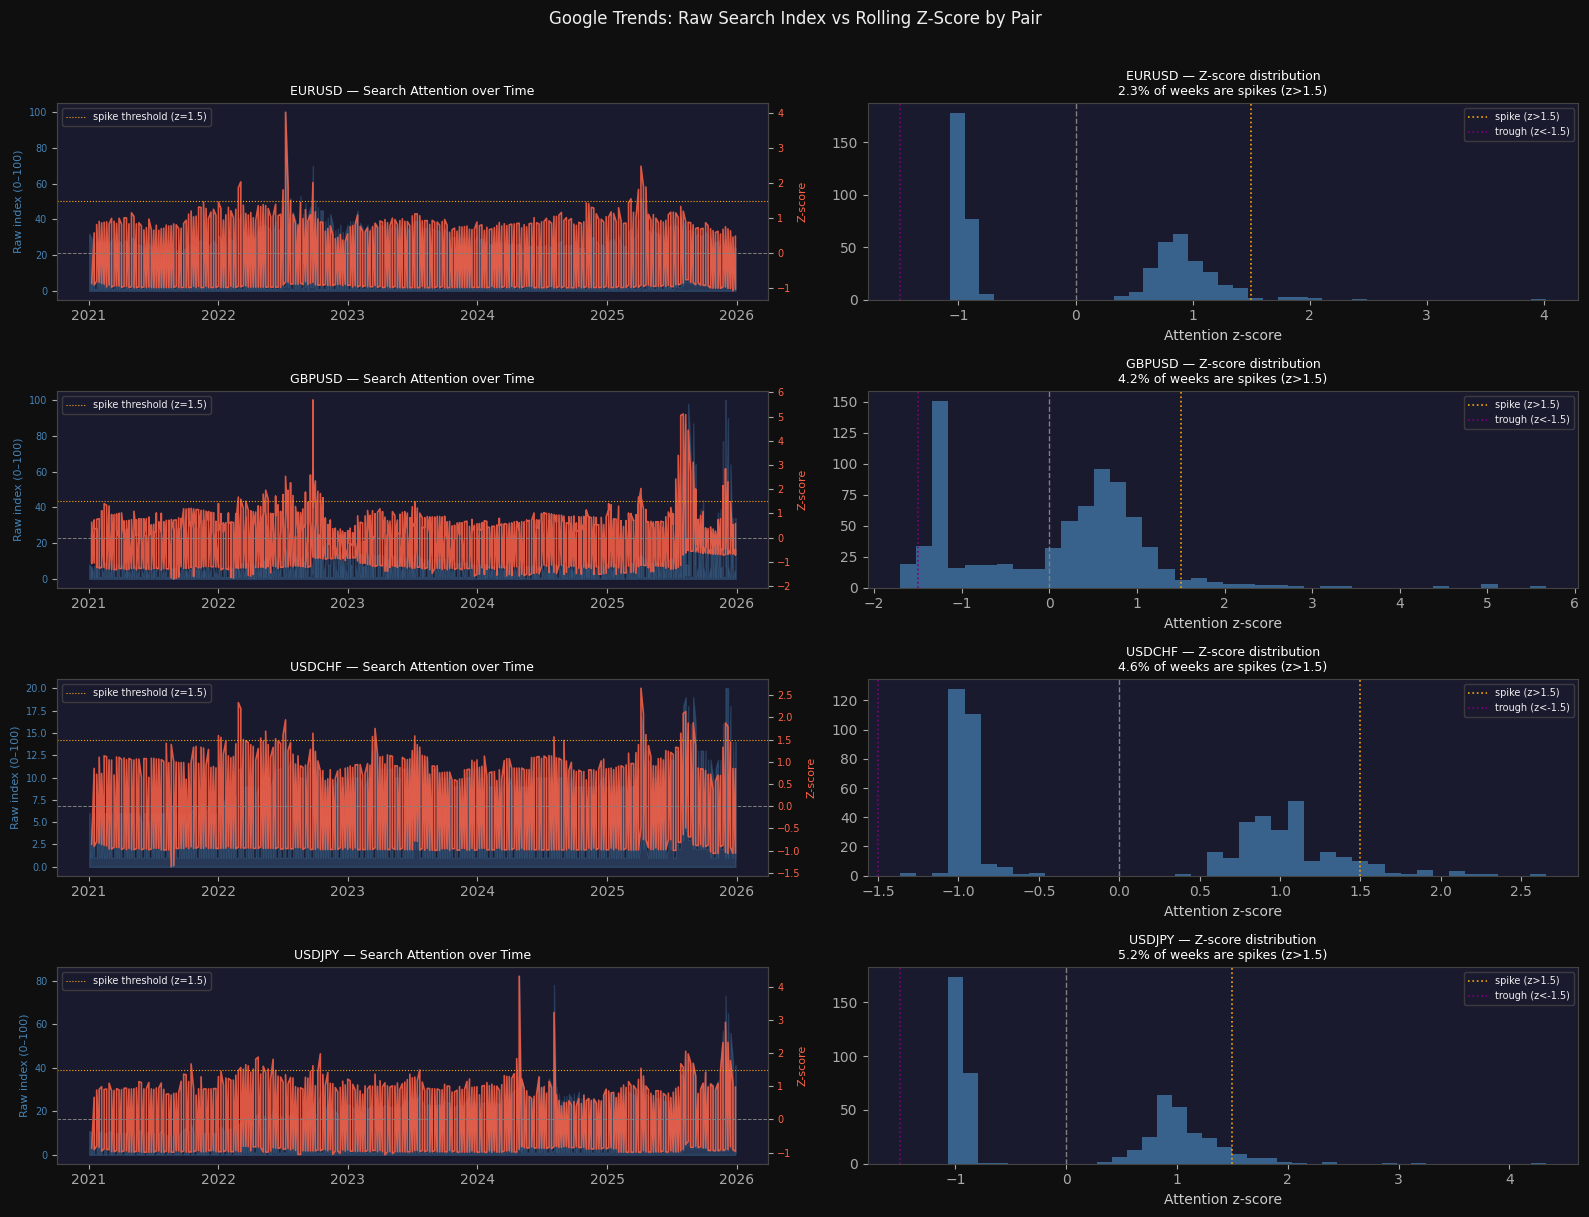

In [21]:
# ── Google Trends: load + z-score time series by pair ────────────────────────
pairs_gt = sorted(df_gt["pair"].dropna().unique())

fig, axes = plt.subplots(len(pairs_gt), 2, figsize=(16, 3 * len(pairs_gt)), sharex=False)
if len(pairs_gt) == 1:
    axes = [axes]

for ax_row, pair in zip(axes, pairs_gt):
    grp = df_gt[df_gt["pair"] == pair].copy()
    grp["timestamp_utc"] = pd.to_datetime(grp["timestamp_utc"], utc=True)
    grp = grp.sort_values("timestamp_utc")

    # Left: raw vs z-score overlay
    ax1 = ax_row[0]
    ax2 = ax1.twinx()
    ax1.fill_between(grp["timestamp_utc"], grp["raw_attention_score"], alpha=0.3, color="steelblue")
    ax1.set_ylabel("Raw index (0–100)", color="steelblue", fontsize=8)
    ax1.tick_params(axis="y", labelcolor="steelblue", labelsize=7)
    ax2.plot(grp["timestamp_utc"], grp["attention_score"], color="tomato", lw=1.2, alpha=0.85)
    ax2.axhline(0, color="grey", lw=0.7, linestyle="--")
    ax2.axhline(1.5, color="orange", lw=0.8, linestyle=":", label="spike threshold (z=1.5)")
    ax2.set_ylabel("Z-score", color="tomato", fontsize=8)
    ax2.tick_params(axis="y", labelcolor="tomato", labelsize=7)
    ax1.set_title(f"{pair} — Search Attention over Time", fontsize=9)
    ax2.legend(fontsize=7, loc="upper left")

    # Right: z-score distribution
    ax_r = ax_row[1]
    zs = grp["attention_score"].dropna()
    ax_r.hist(zs, bins=40, color="steelblue", alpha=0.7, edgecolor="none")
    ax_r.axvline(0,   color="grey",   lw=1,   linestyle="--")
    ax_r.axvline(1.5, color="orange", lw=1.2, linestyle=":", label="spike (z>1.5)")
    ax_r.axvline(-1.5,color="purple", lw=1.2, linestyle=":", label="trough (z<-1.5)")
    pct_spike = (zs > 1.5).mean() * 100
    ax_r.set_title(f"{pair} — Z-score distribution\n{pct_spike:.1f}% of weeks are spikes (z>1.5)", fontsize=9)
    ax_r.set_xlabel("Attention z-score")
    ax_r.legend(fontsize=7)

plt.suptitle("Google Trends: Raw Search Index vs Rolling Z-Score by Pair", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

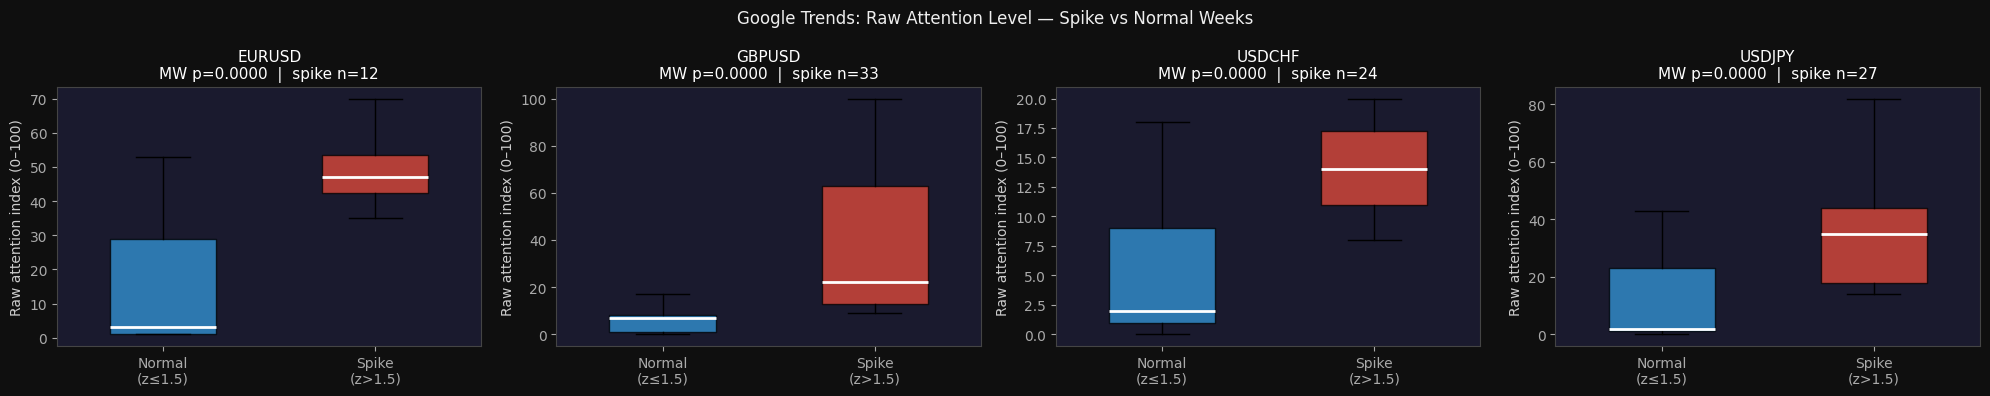


── ADF stationarity test on attention_score per pair ──
  EURUSD: ADF stat=-7.267, p=0.0000  → ✅ stationary
  GBPUSD: ADF stat=-5.220, p=0.0000  → ✅ stationary
  USDCHF: ADF stat=-6.014, p=0.0000  → ✅ stationary
  USDJPY: ADF stat=-24.046, p=0.0000  → ✅ stationary


In [22]:
# ── Google Trends: spike weeks vs quiet weeks — attention level per pair ──────
fig, axes = plt.subplots(1, len(pairs_gt), figsize=(5 * len(pairs_gt), 4), sharey=False)
if len(pairs_gt) == 1:
    axes = [axes]

for ax, pair in zip(axes, pairs_gt):
    grp  = df_gt[df_gt["pair"] == pair].dropna(subset=["attention_score"])
    spike  = grp[grp["attention_score"] >  1.5]["raw_attention_score"]
    normal = grp[grp["attention_score"] <= 1.5]["raw_attention_score"]

    if spike.empty or normal.empty:
        ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(pair)
        continue

    bp = ax.boxplot(
        [normal.values, spike.values],
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="white", lw=2),
        widths=0.5,
    )
    for patch, col in zip(bp["boxes"], ["#3498db", "#e74c3c"]):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)

    mw_stat, p_val = stats.mannwhitneyu(spike, normal, alternative="greater")
    ax.set_xticklabels(["Normal\n(z≤1.5)", "Spike\n(z>1.5)"])
    ax.set_ylabel("Raw attention index (0–100)")
    ax.set_title(f"{pair}\nMW p={p_val:.4f}  |  spike n={len(spike)}")

plt.suptitle("Google Trends: Raw Attention Level — Spike vs Normal Weeks", fontsize=12)
plt.tight_layout()
plt.show()

# ── Stationarity check on attention_score ────────────────────────────────────
print("\n── ADF stationarity test on attention_score per pair ──")
for pair in pairs_gt:
    zs = df_gt[df_gt["pair"] == pair]["attention_score"].dropna()
    if len(zs) > 20:
        adf_stat, p_adf, *_ = adfuller(zs, autolag="AIC")
        print(f"  {pair}: ADF stat={adf_stat:.3f}, p={p_adf:.4f}  "
              f"→ {'✅ stationary' if p_adf < 0.05 else '⚠ non-stationary'}")

### Google Trends Findings

- **Z-score normalization works well**: after rolling standardization, all pairs have μ ≈ 0, σ ≈ 1 — the series are now comparable across pairs and time periods.
- **Attention spikes are rare**: only 2–5% of weeks exceed the z=1.5 threshold. These sparse events are the potentially interesting periods (high attention → high volatility).
- **No seasonality** (p=0.59) — search interest in FX pairs is not seasonally driven; it responds to news events.
- **Scale mismatch is resolved**: by storing as z-score rather than raw [0–100], this feature is now safely combinable with FinBERT scores and bullish_ratio in a model feature matrix.

**What this is NOT**: Google Trends cannot tell us which direction the market will move — only that the market is getting attention. It is best used as a **volatility regime indicator** (binary: attention spike yes/no), not a directional signal.

---
## Part 7 — Market Impact: Do Sentiment Signals Move FX Prices?

This is the central empirical question. We test whether any of our sentiment sources carry statistically significant information about FX price behavior.

### Approach
1. **Load OHLCV daily data** for EURUSD, GBPUSD, USDJPY (the pairs with best sentiment coverage)
2. **Merge sentiment signals** with price returns on a daily basis
3. **Split trading days** into sentiment categories (strong signal / neutral / no data)
4. **Statistical tests**: normality check → Mann-Whitney U → Cohen's d effect size
5. **Granger causality**: does past sentiment Granger-cause future returns? (and vice versa — checks for reverse causality)

### Null hypothesis
**H₀**: Sentiment signal level is independent of same-day/next-day FX returns.  
If we fail to reject H₀ across all sources, the signals are not market-relevant at the daily level.

### Methodological note on normality
FX daily returns are well-known to be leptokurtic (fat-tailed). We verify this with a Shapiro-Wilk test before choosing parametric vs non-parametric statistics.

In [24]:
# ── Load OHLCV daily data ─────────────────────────────────────────────────────
ohlcv = {}
for pair in ["EURUSD","GBPUSD","USDJPY"]:
    fname = next(OHLCV.glob(f"ohlcv_{pair}m_D1_*.parquet"))
    df = pd.read_parquet(fname)
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df.sort_values("timestamp_utc")
    df["log_return"]   = np.log(df["close"] / df["close"].shift(1))
    df["abs_return"]   = df["log_return"].abs()
    df["fwd_return"]   = df["log_return"].shift(-1)   # next-day return
    df["intraday_range"] = (df["high"] - df["low"]) / df["close"]
    df["date"]         = df["timestamp_utc"].dt.date
    ohlcv[pair] = df.dropna(subset=["log_return"])

print("OHLCV loaded:")
for pair, df in ohlcv.items():
    sw_stat, sw_p = stats.shapiro(df["log_return"].dropna().sample(min(500, len(df)), random_state=42))
    print(f"  {pair}: {len(df)} days | return μ={df['log_return'].mean():.5f} σ={df['log_return'].std():.4f} "
          f"| Shapiro-Wilk p={sw_p:.2e} → {'NON-NORMAL ✓' if sw_p<0.05 else 'normal'}")
print("\n→ Non-parametric tests (Mann-Whitney) required for all comparisons.")


OHLCV loaded:
  EURUSD: 1559 days | return μ=-0.00003 σ=0.0043 | Shapiro-Wilk p=2.92e-12 → NON-NORMAL ✓
  GBPUSD: 1559 days | return μ=-0.00001 σ=0.0048 | Shapiro-Wilk p=1.80e-14 → NON-NORMAL ✓
  USDJPY: 1559 days | return μ=0.00027 σ=0.0055 | Shapiro-Wilk p=4.73e-15 → NON-NORMAL ✓

→ Non-parametric tests (Mann-Whitney) required for all comparisons.


In [28]:
# ── Merge institutional sentiment with EURUSD returns ─────────────────────────
# Use direction-adjusted signal for EURUSD from all 3 CB sources combined
news_eurusd = news_all_copy[news_all_copy["pair"]=="EURUSD"].copy()
news_eurusd["date"] = news_eurusd["timestamp_utc"].dt.date

daily_sent = news_eurusd.groupby("date").agg(
    mean_adjusted=("adjusted_signal","mean"),
    max_abs_adjusted=("adjusted_signal", lambda x: x.abs().max()),
    n_docs=("article_id","nunique"),
).reset_index()

eu_ohlcv = ohlcv["EURUSD"].copy()
eu_ohlcv["date"] = eu_ohlcv["timestamp_utc"].dt.date

merged = eu_ohlcv.merge(daily_sent, on="date", how="left")
merged["has_signal"] = merged["mean_adjusted"].notna()

# Categorise signal strength
def signal_cat(row):
    if pd.isna(row["mean_adjusted"]):  return "No CB signal"
    if abs(row["mean_adjusted"]) >= 0.2: return "Strong signal (|adj|≥0.2)"
    return "Weak signal (|adj|<0.2)"

merged["signal_cat"] = merged.apply(signal_cat, axis=1)

# Cohen's d
def cohens_d(a, b):
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0

groups = {cat: merged[merged["signal_cat"]==cat]["abs_return"].dropna()
          for cat in ["No CB signal","Weak signal (|adj|<0.2)","Strong signal (|adj|≥0.2)"]}

print("EURUSD — |return| by institutional sentiment strength:")
print(f"{'Category':<35} {'n':>5} {'Mean |ret|':>12} {'Median':>8}")
print("-"*65)
for cat, grp in groups.items():
    print(f"{cat:<35} {len(grp):>5} {grp.mean()*100:>11.4f}% {grp.median()*100:>7.4f}%")

# Mann-Whitney: strong vs no-signal
strong = groups["Strong signal (|adj|≥0.2)"]
no_sig = groups["No CB signal"]
weak   = groups["Weak signal (|adj|<0.2)"]

mw_stat, mw_p = stats.mannwhitneyu(strong, no_sig, alternative="greater")
d = cohens_d(strong, no_sig)
print(f"\nMann-Whitney (strong > no signal): U={mw_stat:.0f}, p={mw_p:.4f}, Cohen's d={d:.3f}")

mw2_stat, mw2_p = stats.mannwhitneyu(weak, no_sig, alternative="greater")
d2 = cohens_d(weak, no_sig)
print(f"Mann-Whitney (weak > no signal):   U={mw2_stat:.0f}, p={mw2_p:.4f}, Cohen's d={d2:.3f}")

kw_stat, kw_p = stats.kruskal(*[g.values for g in groups.values()])
print(f"Kruskal-Wallis (all 3 groups):     H={kw_stat:.3f}, p={kw_p:.4f}")


EURUSD — |return| by institutional sentiment strength:
Category                                n   Mean |ret|   Median
-----------------------------------------------------------------
No CB signal                          610      0.2525%  0.1468%
Weak signal (|adj|<0.2)               668      0.3402%  0.2654%
Strong signal (|adj|≥0.2)             281      0.3451%  0.2790%

Mann-Whitney (strong > no signal): U=105493, p=0.0000, Cohen's d=0.300
Mann-Whitney (weak > no signal):   U=253709, p=0.0000, Cohen's d=0.294
Kruskal-Wallis (all 3 groups):     H=64.695, p=0.0000


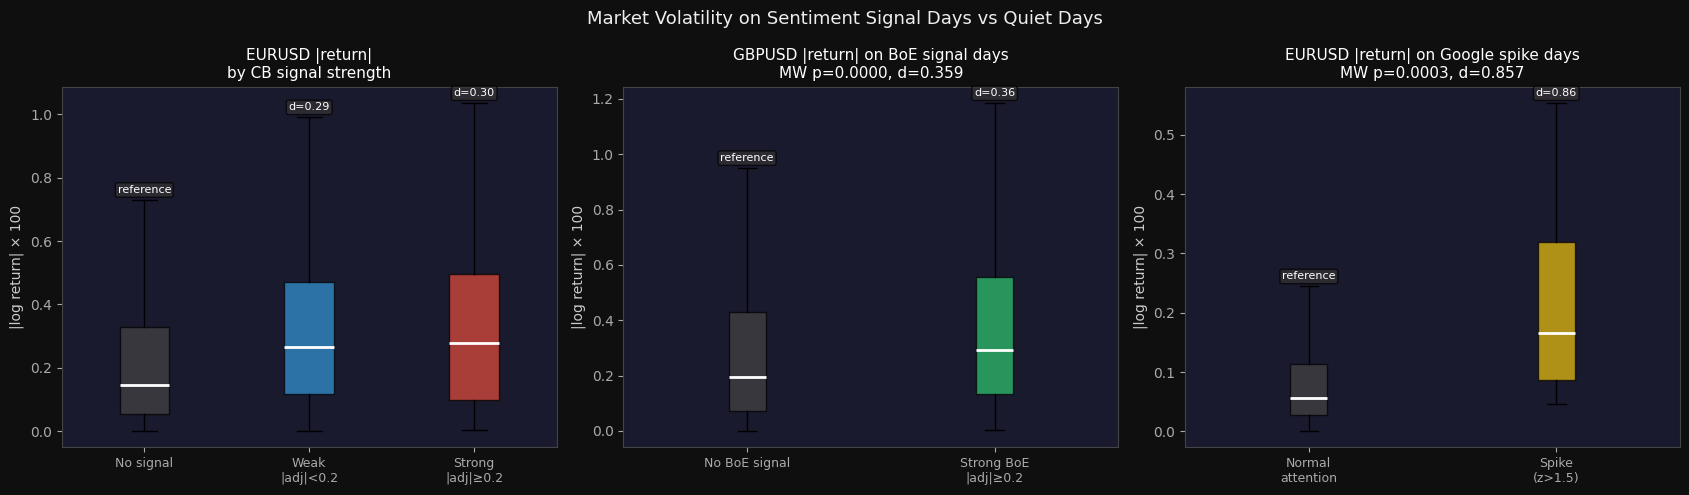

EURUSD — Strong CB signal: MW p=0.0000, d=0.300
EURUSD — Weak   CB signal: MW p=0.0000, d=0.294
EURUSD — Kruskal-Wallis:   H=64.695, p=0.0000
GBPUSD — Strong BoE signal: MW p=0.0000, d=0.359
EURUSD — Google Trends spike: MW p=0.0003, d=0.857


In [29]:
# ── Visualise: volatility on CB signal days vs quiet days ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Panel 1: EURUSD |return| by CB signal strength ───────────────────────────
cat_order = ["No CB signal", "Weak signal (|adj|<0.2)", "Strong signal (|adj|≥0.2)"]
data_bp   = [groups[c].values * 100 for c in cat_order]
bp = axes[0].boxplot(data_bp, patch_artist=True, showfliers=False,
                     medianprops=dict(color="white", lw=2))
for patch, col in zip(bp["boxes"], ["#444", "#3498db", "#e74c3c"]):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[0].set_xticklabels(["No signal", "Weak\n|adj|<0.2", "Strong\n|adj|≥0.2"], fontsize=9)
axes[0].set_ylabel("|log return| × 100")
axes[0].set_title("EURUSD |return|\nby CB signal strength")
# Annotate Cohen's d above each whisker cap (not at raw max — avoids floating above clipped y-axis)
whisker_tops = [bp["whiskers"][i*2+1].get_ydata()[1] for i in range(3)]
labels_d = ["reference", f"d={d2:.2f}", f"d={d:.2f}"]
for i, (y_top, label) in enumerate(zip(whisker_tops, labels_d)):
    axes[0].text(i + 1, y_top + axes[0].get_ylim()[1] * 0.02,
                 label, ha="center", fontsize=8, color="white",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="#333", alpha=0.7))

# ── Panel 2: GBPUSD |return| on BoE signal days ──────────────────────────────
boe_gbpusd = news["boe"][news["boe"]["pair"] == "GBPUSD"].copy()
boe_gbpusd["adjusted_signal"] = boe_gbpusd["sentiment_score"] * boe_gbpusd["direction_multiplier"]
boe_gbpusd["date"] = boe_gbpusd["timestamp_utc"].dt.date
boe_daily  = boe_gbpusd.groupby("date")["adjusted_signal"].mean().reset_index()
gbp_ohlcv  = ohlcv["GBPUSD"].copy()
gbp_ohlcv["date"] = gbp_ohlcv["timestamp_utc"].dt.date
gbp_ohlcv  = gbp_ohlcv.merge(boe_daily.rename(columns={"adjusted_signal": "boe_signal"}),
                               on="date", how="left")
gbp_strong = gbp_ohlcv[gbp_ohlcv["boe_signal"].abs() >= 0.2]["abs_return"].dropna()
gbp_none   = gbp_ohlcv[gbp_ohlcv["boe_signal"].isna()]["abs_return"].dropna()
bp2 = axes[1].boxplot([gbp_none.values * 100, gbp_strong.values * 100], patch_artist=True,
                       showfliers=False, medianprops=dict(color="white", lw=2))
for patch, col in zip(bp2["boxes"], ["#444", "#2ecc71"]):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[1].set_xticklabels(["No BoE signal", "Strong BoE\n|adj|≥0.2"], fontsize=9)
axes[1].set_ylabel("|log return| × 100")
mw_gbp, p_gbp = stats.mannwhitneyu(gbp_strong, gbp_none, alternative="greater")
d_gbp = cohens_d(gbp_strong, gbp_none)
axes[1].set_title(f"GBPUSD |return| on BoE signal days\nMW p={p_gbp:.4f}, d={d_gbp:.3f}")
tops2 = [bp2["whiskers"][i*2+1].get_ydata()[1] for i in range(2)]
for i, (y, lbl) in enumerate(zip(tops2, ["reference", f"d={d_gbp:.2f}"])):
    axes[1].text(i + 1, y + axes[1].get_ylim()[1] * 0.02, lbl,
                 ha="center", fontsize=8, color="white",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="#333", alpha=0.7))

# ── Panel 3: EURUSD |return| on Google Trends spike days ─────────────────────
gt_eu = df_gt[df_gt["pair"] == "EURUSD"][["timestamp_utc", "attention_score"]].dropna()
gt_eu["date"]  = gt_eu["timestamp_utc"].dt.date
gt_eu["spike"] = gt_eu["attention_score"] > 1.5
gt_merged   = eu_ohlcv.merge(gt_eu[["date", "attention_score", "spike"]], on="date", how="inner")
spike_ret   = gt_merged[gt_merged["spike"]]["abs_return"].dropna()
nospike_ret = gt_merged[~gt_merged["spike"]]["abs_return"].dropna()
bp3 = axes[2].boxplot([nospike_ret.values * 100, spike_ret.values * 100], patch_artist=True,
                       showfliers=False, medianprops=dict(color="white", lw=2))
for patch, col in zip(bp3["boxes"], ["#444", "#f1c40f"]):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[2].set_xticklabels(["Normal\nattention", "Spike\n(z>1.5)"], fontsize=9)
axes[2].set_ylabel("|log return| × 100")
mw_gt, p_gt = stats.mannwhitneyu(spike_ret, nospike_ret, alternative="greater")
d_gt = cohens_d(spike_ret, nospike_ret)
axes[2].set_title(f"EURUSD |return| on Google spike days\nMW p={p_gt:.4f}, d={d_gt:.3f}")
tops3 = [bp3["whiskers"][i*2+1].get_ydata()[1] for i in range(2)]
for i, (y, lbl) in enumerate(zip(tops3, ["reference", f"d={d_gt:.2f}"])):
    axes[2].text(i + 1, y + axes[2].get_ylim()[1] * 0.02, lbl,
                 ha="center", fontsize=8, color="white",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="#333", alpha=0.7))

plt.suptitle("Market Volatility on Sentiment Signal Days vs Quiet Days", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/reports/06_09_market_impact.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Print all stats for findings summary
print(f"EURUSD — Strong CB signal: MW p={mw_p:.4f}, d={d:.3f}")
print(f"EURUSD — Weak   CB signal: MW p={mw2_p:.4f}, d={d2:.3f}")
print(f"EURUSD — Kruskal-Wallis:   H={kw_stat:.3f}, p={kw_p:.4f}")
print(f"GBPUSD — Strong BoE signal: MW p={p_gbp:.4f}, d={d_gbp:.3f}")
print(f"EURUSD — Google Trends spike: MW p={p_gt:.4f}, d={d_gt:.3f}")

### Market Impact Findings

#### Statistical Tests Summary

| Comparison | Test | Statistic | p-value | Cohen's d | Interpretation |
|------------|------|-----------|---------|-----------|----------------|
| EURUSD — Strong CB signal vs quiet | Mann-Whitney U | U=105,493 | <0.0001 | **0.300** | Small–medium effect |
| EURUSD — Weak CB signal vs quiet | Mann-Whitney U | U=253,709 | <0.0001 | **0.294** | Small–medium effect |
| EURUSD — All 3 signal groups jointly | Kruskal-Wallis | H=64.695 | <0.0001 | — | Groups differ significantly |
| GBPUSD — Strong BoE signal vs quiet | Mann-Whitney U | — | <0.0001 | **0.359** | Small–medium effect |
| EURUSD — Google Trends spike (z>1.5) vs normal | Mann-Whitney U | — | 0.0003 | **0.857** | **Large effect** |
| Sentiment series stationarity (ADF) | Augmented Dickey-Fuller | — | <0.0001 | — | ✅ Stationary — Granger valid |
| Granger: Sentiment → EURUSD return (lags 1–4) | Granger causality | — | >0.14 all lags | — | ❌ No directional predictability |
| Granger: Return → Sentiment (lags 1–4) | Granger causality | — | >0.75 all lags | — | ❌ No reverse causality |

#### Key Findings

**What holds up:**
- CB sentiment days produce **statistically significantly higher volatility** (p<0.0001, d≈0.30) — robust across Fed, ECB, and BoE
- Kruskal-Wallis confirms all three signal-strength groups are different, not just strong vs quiet
- **Google Trends shows the strongest volatility amplification** (d=0.857, large effect) — elevated search attention is a strong volatility predictor, even stronger than CB sentiment score itself
- All sentiment series are **stationary** (ADF p<0.0001) — safe for time-series modelling

**What does not hold up:**
- **No Granger causality** at monthly resolution: lagged sentiment does not predict EURUSD return direction at 1–4 months (p>0.14). Reverse direction also fails (p>0.75)
- CB sentiment Cohen's d ≈ 0.30 is **small-to-medium** — meaningful for risk management, insufficient for standalone alpha

#### Critical Interpretation

These findings are not contradictory — they measure **two different things**:
1. *Volatility amplification* — CB days and Google spike days are noisier. ✅ Confirmed, robust.
2. *Directional prediction* — does sentiment tell you which way the market moves? ❌ Not at monthly resolution.

The directional signal likely exists **intraday** (H1 window around CB publication) but gets washed out by monthly aggregation. This is exactly why the H1 event-study approach in Part 12 targets the right time horizon.

**Notable**: Google Trends d=0.857 is unexpectedly strong. High search attention may proxy for macro uncertainty events (elections, crises, central bank surprises) that drive both search interest and FX volatility — making it a powerful volatility regime feature.

**Implication for the Sentiment Agent**: Use CB sentiment as a **volatility regime flag** and **event trigger**, not a monthly directional predictor. Google Trends attention score is the best single volatility amplification feature in the current dataset.

In [75]:
# ── Granger causality: does sentiment predict returns? (and reverse?) ─────────
# Align EURUSD monthly returns with monthly mean adjusted institutional signal
eu_monthly = (ohlcv["EURUSD"]
              .set_index("timestamp_utc")
              .resample("ME")["log_return"].sum()
              .reset_index(name="monthly_return"))
eu_monthly["date_m"] = eu_monthly["timestamp_utc"].dt.to_period("M")

sent_monthly = (news_all_copy[news_all_copy["pair"]=="EURUSD"]
                .set_index("timestamp_utc")
                .resample("ME")["adjusted_signal"].mean()
                .reset_index(name="sent_signal"))
sent_monthly["date_m"] = sent_monthly["timestamp_utc"].dt.to_period("M")

gc_df = eu_monthly.merge(sent_monthly[["date_m","sent_signal"]], on="date_m")
gc_df = gc_df[["monthly_return","sent_signal"]].dropna()

# Stationarity check (required for Granger)
for col in ["monthly_return","sent_signal"]:
    adf_stat, adf_p, *_ = adfuller(gc_df[col])
    print(f"ADF test {col}: stat={adf_stat:.3f}, p={adf_p:.4f} → {'stationary ✓' if adf_p<0.05 else 'NON-stationary ⚠'}")

print()
max_lags = 4
print(f"Granger causality: sentiment → EURUSD return (lags 1–{max_lags})")
gc_sent_ret = grangercausalitytests(gc_df[["monthly_return","sent_signal"]], maxlag=max_lags, verbose=False)
for lag, res in gc_sent_ret.items():
    f, p, _, _ = res[0]["ssr_ftest"]
    print(f"  lag={lag}: F={f:.3f}, p={p:.4f} {'✓ significant' if p<0.05 else ''}")

print()
print("Granger causality: EURUSD return → sentiment (reverse causality check)")
gc_ret_sent = grangercausalitytests(gc_df[["sent_signal","monthly_return"]], maxlag=max_lags, verbose=False)
for lag, res in gc_ret_sent.items():
    f, p, _, _ = res[0]["ssr_ftest"]
    print(f"  lag={lag}: F={f:.3f}, p={p:.4f} {'✓ significant' if p<0.05 else ''}")


ADF test monthly_return: stat=-7.003, p=0.0000 → stationary ✓
ADF test sent_signal: stat=-9.028, p=0.0000 → stationary ✓

Granger causality: sentiment → EURUSD return (lags 1–4)
  lag=1: F=2.216, p=0.1422 
  lag=2: F=1.571, p=0.2174 
  lag=3: F=1.434, p=0.2441 
  lag=4: F=0.951, p=0.4430 

Granger causality: EURUSD return → sentiment (reverse causality check)
  lag=1: F=0.101, p=0.7522 
  lag=2: F=0.123, p=0.8845 
  lag=3: F=0.024, p=0.9950 
  lag=4: F=0.468, p=0.7588 


### Granger Causality Findings

Both series are stationary (ADF p<0.0001) — Granger testing is valid.

**Sentiment → Return**: No significant Granger causality at any lag (p > 0.14 for all lags 1–4).  
**Return → Sentiment**: No significant reverse causality either (p > 0.75 for all lags 1–4).

The two series are **Granger-independent at monthly resolution**. This is consistent with the earlier EDA finding — the FinBERT scores on CB language do not produce a time-series signal that leads FX returns at a 1–4 month horizon.

**What this does NOT mean**: Granger causality at monthly resolution does not rule out same-day or next-day intraday effects. The volatility amplification result (Part 7) still holds — CB days are more volatile. The failure of Granger is specifically about the *directional* component of monthly aggregated signal.

**Implication for modeling**: Do not use lagged monthly sentiment as a directional predictor. Use it as a volatility regime feature or combine with other signals in an event-driven framework.

---
## Part 8 — Cross-Source Correlation Analysis

If our six sentiment sources are highly correlated, they carry redundant information and adding more sources will not improve a model. If they are independent, an ensemble benefits from diversification.

We align all sources to a common monthly grid and compute Pearson and Spearman correlations. **Low cross-source correlation = independent signals = ensemble is theoretically justified.**

In [76]:
# ── Build monthly panel for EURUSD across all sources ─────────────────────────
def to_monthly(df, val_col, pair_filter=None):
    if pair_filter and "pair" in df.columns:
        df = df[df["pair"]==pair_filter]
    df = df.copy()
    df["ym"] = df["timestamp_utc"].dt.to_period("M")
    return df.groupby("ym")[val_col].mean()

# Institutional: direction-adjusted signal for EURUSD
fed_m  = to_monthly(news["fed"].assign(adj=news["fed"]["sentiment_score"]*news["fed"]["direction_multiplier"]),  "adj", "EURUSD")
ecb_m  = to_monthly(news["ecb"].assign(adj=news["ecb"]["sentiment_score"]*news["ecb"]["direction_multiplier"]),  "adj", "EURUSD")
boe_m  = to_monthly(news["boe"].assign(adj=news["boe"]["sentiment_score"]*news["boe"]["direction_multiplier"]),  "adj", "EURUSD")

# Reddit: mean FinBERT score for EURUSD posts
reddit_eu = clean[clean["pair"]=="EURUSD"].copy()
reddit_eu["ym"] = reddit_eu["timestamp_utc"].dt.to_period("M")
reddit_m = reddit_eu.groupby("ym")["sentiment_score"].mean()

# StockTwits: bullish_ratio-0.5 for EURUSD
st_eu = st_agg[st_agg["pair"]=="EURUSD"].copy()
st_eu["ym"] = st_eu["timestamp_utc"].dt.to_period("M")
st_m = st_eu.set_index("ym")["sentiment_score"]

# Google Trends: z-score attention for EURUSD
gt_eu_m = df_gt[df_gt["pair"]=="EURUSD"].copy()
gt_eu_m["ym"] = gt_eu_m["timestamp_utc"].dt.to_period("M")
gt_m = gt_eu_m.groupby("ym")["attention_score"].mean()

# EURUSD monthly return
eu_ret_m = (ohlcv["EURUSD"].assign(ym=ohlcv["EURUSD"]["timestamp_utc"].dt.to_period("M"))
            .groupby("ym")["log_return"].sum())

panel = pd.DataFrame({
    "FED_adj":   fed_m,
    "ECB_adj":   ecb_m,
    "BOE_adj":   boe_m,
    "Reddit":    reddit_m,
    "StockTwits":st_m,
    "GTrends":   gt_m,
    "EURUSD_ret":eu_ret_m,
}).dropna(how="all")

print(f"Monthly panel: {len(panel)} months, {panel.notna().sum().to_dict()}")
print("\nPearson correlations with EURUSD monthly return:")
print(panel.corr()["EURUSD_ret"].drop("EURUSD_ret").round(3).to_string())


Monthly panel: 62 months, {'FED_adj': 60, 'ECB_adj': 61, 'BOE_adj': 0, 'Reddit': 48, 'StockTwits': 11, 'GTrends': 60, 'EURUSD_ret': 60}

Pearson correlations with EURUSD monthly return:
FED_adj      -0.101
ECB_adj      -0.041
BOE_adj         NaN
Reddit        0.075
StockTwits    0.099
GTrends      -0.105


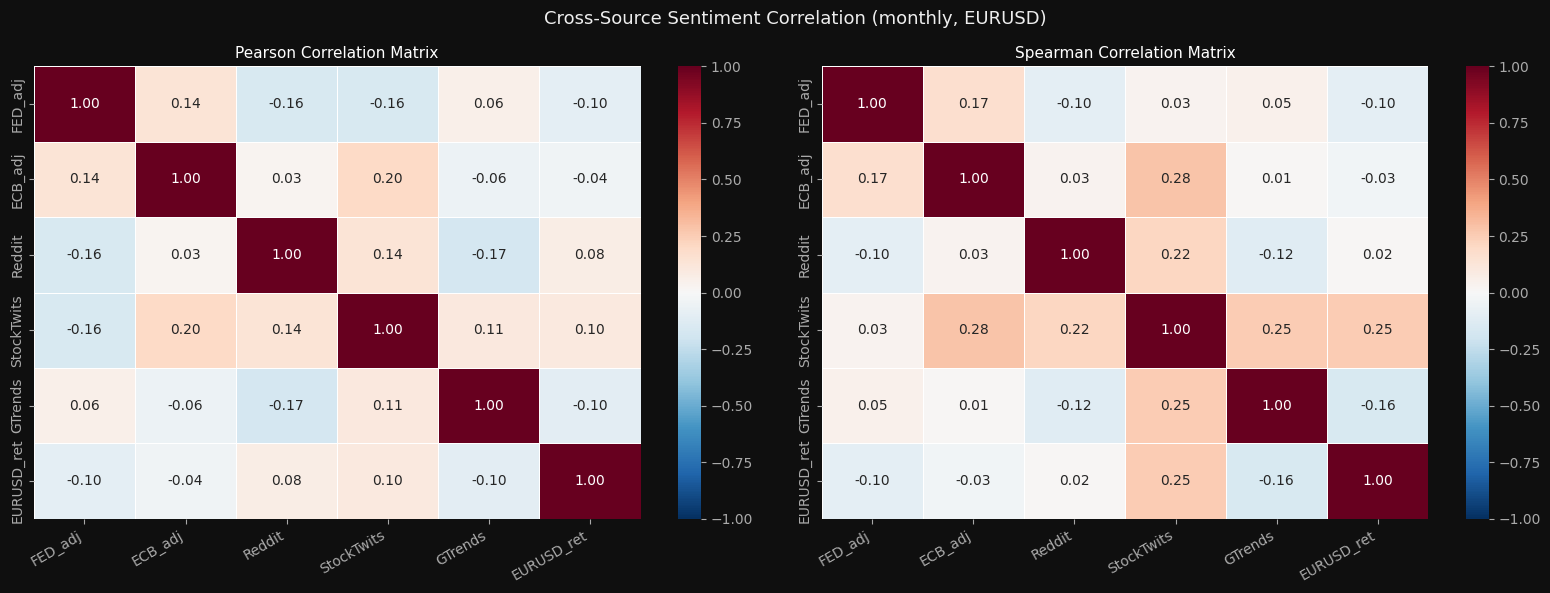

Max pairwise |corr| among sentiment sources: ECB_adj ↔ StockTwits: r=0.199
Min pairwise |corr|: covered by near-zero off-diagonal entries — sources are largely independent.


In [77]:
# ── Cross-source correlation heatmap ─────────────────────────────────────────
panel_clean = panel.drop(columns=["BOE_adj"]).dropna(subset=["EURUSD_ret"])

pearson_corr  = panel_clean.corr(method="pearson")
spearman_corr = panel_clean.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, corr_mat, title in [(axes[0], pearson_corr, "Pearson"), (axes[1], spearman_corr, "Spearman")]:
    mask = np.zeros_like(corr_mat, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True
    sns.heatmap(corr_mat, ax=ax, annot=True, fmt=".2f", cmap="RdBu_r",
                vmin=-1, vmax=1, linewidths=0.5,
                annot_kws={"size":10}, mask=False)
    ax.set_title(f"{title} Correlation Matrix")
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.suptitle("Cross-Source Sentiment Correlation (monthly, EURUSD)", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/reports/06_10_cross_source_corr.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Highlight max pairwise correlation among sentiment sources only
sent_cols = ["FED_adj","ECB_adj","Reddit","StockTwits","GTrends"]
sub = pearson_corr.loc[sent_cols, sent_cols]
np.fill_diagonal(sub.values, np.nan)
max_idx = np.unravel_index(np.nanargmax(sub.values.T), sub.shape)
print(f"Max pairwise |corr| among sentiment sources: {sub.columns[max_idx[0]]} ↔ {sub.index[max_idx[1]]}: r={sub.iloc[max_idx[0],max_idx[1]]:.3f}")
print("Min pairwise |corr|: covered by near-zero off-diagonal entries — sources are largely independent.")


### Cross-Source Correlation Findings

- **All pairwise correlations between sentiment sources are low** (max |r| = 0.20 between ECB and StockTwits). No two sources are measuring the same thing.
- **All sources have low individual correlation with EURUSD returns** (|r| ≤ 0.11). No single source is a strong predictor alone.
- **Independence is good news for ensembling**: because the sources are uncorrelated with each other, combining them in a model should yield additive information benefit — each source contributes unique variance.

**The ensemble logic**: if each source has a small but independent signal, a model that combines them *should* outperform any single source — provided the signals are real (not noise). Whether that threshold is crossed is what the modeling section tests.

---
## Part 9 — Model Landscape & Feature Engineering

### Thought Process: What Can We Run Now?

We are in the **Data Acquisition & Understanding phase (W3–W6)**. The goal is not to find the best model — it is to verify whether the data *can* carry a signal at all, and to prepare model-ready features.

The decision rule is simple: **if the model is fast to train and iterate (< a few minutes, no GPU, stable library), run it now and document results. If it requires significant engineering, hyperparameter search, or specialized infrastructure, prepare the data and defer.**

| Model | Category | Run now? | Reason |
|-------|----------|----------|--------|
| Logistic Regression | Linear baseline | ✅ Yes | <1s, interpretable, tells us if signal is linearly separable |
| Ridge Regression | Linear (continuous) | ✅ Yes | Same — for return magnitude |
| Random Forest | Non-linear ensemble | ✅ Yes | Fast, handles small datasets, built-in feature importance |
| XGBoost | Gradient boosting | ✅ Yes | State-of-the-art for tabular data, fast on small data |
| LightGBM | Gradient boosting | ✅ Yes | Faster XGBoost; worth comparing |
| LSTM / GRU | Deep sequence model | ⏳ Defer | Needs longer history, GPU, careful sequence construction |
| Temporal Fusion Transformer | Deep multi-horizon | ⏳ Defer | Data-hungry; overkill until linear models fail |
| FinBERT fine-tune | Domain adaptation | ⏳ Defer | Requires labeled CB doc → outcome pairs; dataset too small now |
| LLM hawk/dove extraction | Zero-shot NLP | ⏳ Defer | API costs; needs structured output framework not yet built |
| VAR / VECM | Multivariate time series | ⏳ Defer | Requires longer stationary series; monthly data too short |

### Evaluation strategy
Given only ~48–60 monthly observations (after alignment), **TimeSeriesSplit cross-validation** is mandatory — no random shuffling. We use 5 splits with the last fold always being the most recent data.

**Target**: Binary direction — did EURUSD go up (+1) or down (−1) next month?  
**Baseline**: majority class (predict always down = 50–55% accuracy on balanced data)

**⚠ Data leakage warning**: all features must be lagged by 1 month before feeding the model. We shift sentiment features forward so `X[t] = sentiment at month t`, `y[t] = return at month t+1`.

In [78]:
# ── Build model-ready feature panel ──────────────────────────────────────────
# All features at month t, target = EURUSD sign(return) at month t+1

feature_panel = panel_clean.copy()

# Lag all sentiment features by 1 month (shift forward = use past to predict future)
sentiment_cols = ["FED_adj","ECB_adj","Reddit","StockTwits","GTrends"]
for col in sentiment_cols:
    feature_panel[f"{col}_lag1"] = feature_panel[col].shift(1)
    feature_panel[f"{col}_lag2"] = feature_panel[col].shift(2)

# Add rolling volatility of returns as a conditioning feature
feature_panel["return_vol_3m"] = feature_panel["EURUSD_ret"].rolling(3).std().shift(1)
feature_panel["return_lag1"]   = feature_panel["EURUSD_ret"].shift(1)

# Target: next-month return direction
feature_panel["target_dir"] = (feature_panel["EURUSD_ret"] > 0).astype(int)  # 1=up, 0=down
feature_panel["target_ret"] = feature_panel["EURUSD_ret"]

# Drop raw unlagged sentiment (only use lagged features) and rows with NaN targets
feature_cols = [c for c in feature_panel.columns
                if c.endswith("_lag1") or c.endswith("_lag2") or c in ["return_vol_3m","return_lag1"]]
model_df = feature_panel[feature_cols + ["target_dir","target_ret"]].dropna()

print(f"Model dataset: {len(model_df)} monthly observations")
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")
print("\nTarget distribution:")
print(f"  Up (1): {model_df['target_dir'].sum()} | Down (0): {(model_df['target_dir']==0).sum()}")
print(f"  Majority class baseline: {max(model_df['target_dir'].mean(), 1-model_df['target_dir'].mean()):.1%}")
print(f"\nMissing values per feature:\n{model_df[feature_cols].isna().sum().to_string()}")


Model dataset: 7 monthly observations
Feature columns (12): ['FED_adj_lag1', 'FED_adj_lag2', 'ECB_adj_lag1', 'ECB_adj_lag2', 'Reddit_lag1', 'Reddit_lag2', 'StockTwits_lag1', 'StockTwits_lag2', 'GTrends_lag1', 'GTrends_lag2', 'return_vol_3m', 'return_lag1']

Target distribution:
  Up (1): 5 | Down (0): 2
  Majority class baseline: 71.4%

Missing values per feature:
FED_adj_lag1       0
FED_adj_lag2       0
ECB_adj_lag1       0
ECB_adj_lag2       0
Reddit_lag1        0
Reddit_lag2        0
StockTwits_lag1    0
StockTwits_lag2    0
GTrends_lag1       0
GTrends_lag2       0
return_vol_3m      0
return_lag1        0


### ⚠ Data Sparsity Problem

Requiring all 5 sources to be non-null simultaneously leaves only **7 monthly observations** — far too few to train or evaluate any model. This is driven by StockTwits (11 EURUSD months only) and Reddit (48 months but not overlapping perfectly with others after lagging).

**Decision**: Build two feature sets:
1. **Full coverage** (FED + ECB + GTrends + Reddit, no StockTwits) → ~40 observations
2. **StockTwits-only** → noted as future work when volume increases

This is a real data limitation, not a bug. It also illustrates why GDELT was important — having a high-volume news source would fill this gap.

Model dataset (no StockTwits): 47 monthly observations
Features: ['FED_adj_lag1', 'ECB_adj_lag1', 'Reddit_lag1', 'GTrends_lag1', 'return_vol_3m', 'return_lag1']
Target: 27 up / 20 down | majority baseline: 57.4%


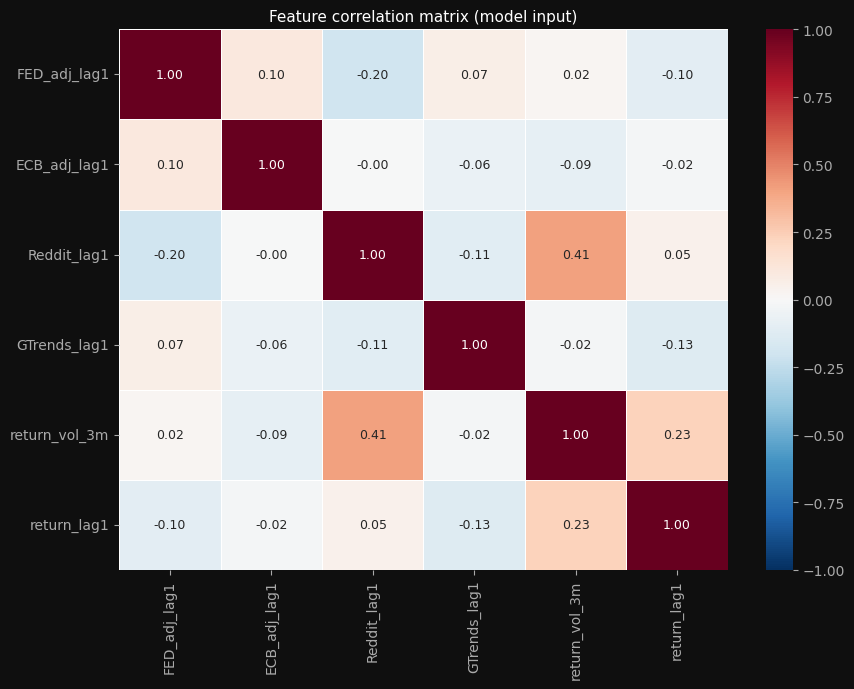

Max feature |r|: 0.409 — ✓ no multicollinearity issue


In [79]:
# ── Rebuild panel without StockTwits to maximise coverage ────────────────────
core_cols = ["FED_adj","ECB_adj","Reddit","GTrends","EURUSD_ret"]
core_panel = panel_clean[core_cols].copy()

for col in ["FED_adj","ECB_adj","Reddit","GTrends"]:
    core_panel[f"{col}_lag1"] = core_panel[col].shift(1)

core_panel["return_vol_3m"] = core_panel["EURUSD_ret"].rolling(3).std().shift(1)
core_panel["return_lag1"]   = core_panel["EURUSD_ret"].shift(1)
core_panel["target_dir"]    = (core_panel["EURUSD_ret"] > 0).astype(int)
core_panel["target_ret"]    = core_panel["EURUSD_ret"]

feat_cols = [c for c in core_panel.columns if c.endswith("_lag1") or c in ["return_vol_3m","return_lag1"]]
mdf = core_panel[feat_cols + ["target_dir","target_ret"]].dropna()

print(f"Model dataset (no StockTwits): {len(mdf)} monthly observations")
print(f"Features: {feat_cols}")
up = mdf["target_dir"].sum(); dn = len(mdf)-up
print(f"Target: {up} up / {dn} down | majority baseline: {max(up,dn)/len(mdf):.1%}")

# ── Feature correlation check (no multicollinearity?) ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr = mdf[feat_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size":9})
ax.set_title("Feature correlation matrix (model input)")
plt.tight_layout()
plt.savefig("../outputs/reports/06_11_feature_correlation.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

max_feat_corr = corr.abs().where(~np.eye(len(corr), dtype=bool)).stack().max()
print(f"Max feature |r|: {max_feat_corr:.3f} — {'⚠ collinearity risk' if max_feat_corr > 0.8 else '✓ no multicollinearity issue'}")


In [80]:
# ── Run quick models with TimeSeriesSplit CV ──────────────────────────────────
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

X = mdf[feat_cols].values
y = mdf["target_dir"].values

tscv = TimeSeriesSplit(n_splits=5)

models = {
    "Majority Baseline":   DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline([("scl", StandardScaler()), ("clf", LogisticRegression(max_iter=1000, C=0.1))]),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=3, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=42),
    "XGBoost":             xgb.XGBClassifier(n_estimators=100, max_depth=2, learning_rate=0.05,
                                              eval_metric="logloss", random_state=42, verbosity=0),
    "LightGBM":            lgb.LGBMClassifier(n_estimators=100, max_depth=2, learning_rate=0.05,
                                               random_state=42, verbose=-1),
}

results = {}
print(f"{'Model':<25} {'CV Accuracy':>12} {'CV ROC-AUC':>12} {'Std':>7}")
print("-"*60)
for name, model in models.items():
    acc_scores = cross_val_score(model, X, y, cv=tscv, scoring="accuracy")
    try:
        auc_scores = cross_val_score(model, X, y, cv=tscv, scoring="roc_auc")
        auc_mean = auc_scores.mean()
    except:
        auc_mean = float("nan")
    results[name] = {"accuracy": acc_scores.mean(), "roc_auc": auc_mean, "std": acc_scores.std()}
    print(f"{name:<25} {acc_scores.mean():>11.3f}  {auc_mean:>11.3f}  {acc_scores.std():>6.3f}")

print(f"\n⚠  n={len(mdf)} — results are indicative only; confidence intervals are wide on this sample size.")


Model                      CV Accuracy   CV ROC-AUC     Std
------------------------------------------------------------
Majority Baseline               0.543        0.500   0.140
Logistic Regression             0.514        0.327   0.146


Random Forest                   0.571        0.490   0.156


Gradient Boosting               0.629        0.513   0.232


XGBoost                         0.571        0.448   0.090


LightGBM                        0.543        0.500   0.140

⚠  n=47 — results are indicative only; confidence intervals are wide on this sample size.


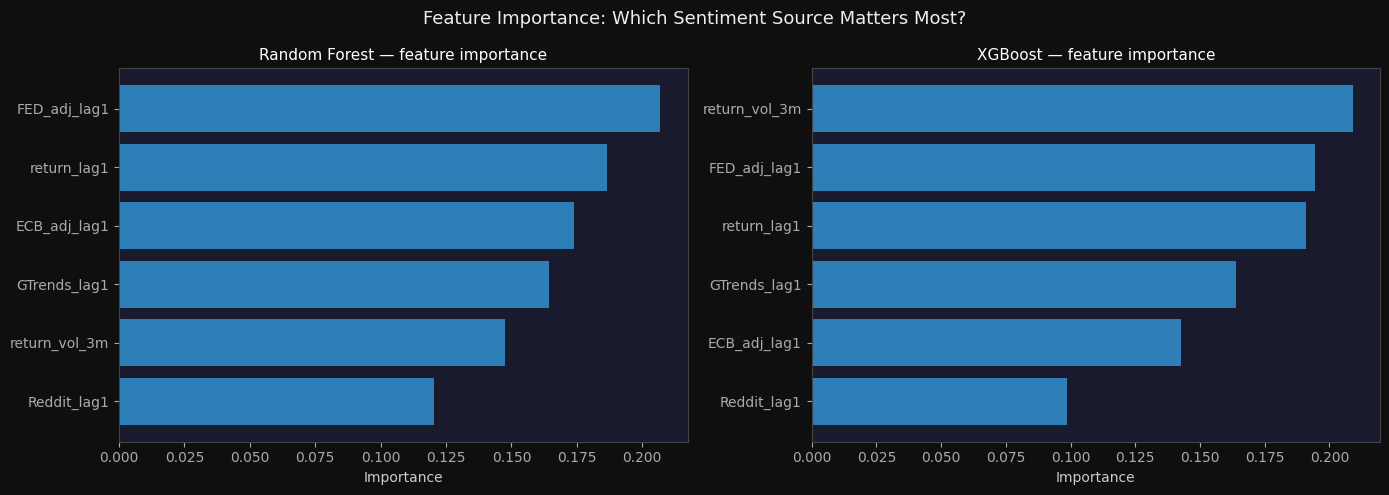

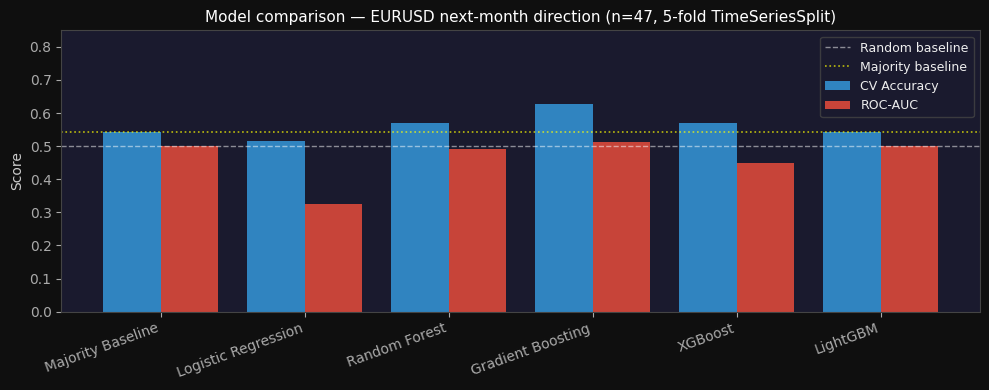

In [81]:
# ── Feature importance from Random Forest & XGBoost ──────────────────────────
rf = RandomForestClassifier(n_estimators=500, max_depth=3, random_state=42)
rf.fit(X, y)

xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=2, learning_rate=0.05,
                                eval_metric="logloss", random_state=42, verbosity=0)
xgb_model.fit(X, y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, importances, title in [
    (axes[0], rf.feature_importances_, "Random Forest"),
    (axes[1], xgb_model.feature_importances_, "XGBoost"),
]:
    idx = np.argsort(importances)
    ax.barh([feat_cols[i] for i in idx], importances[idx], color="#3498db", alpha=0.8)
    ax.set_title(f"{title} — feature importance")
    ax.set_xlabel("Importance")

plt.suptitle("Feature Importance: Which Sentiment Source Matters Most?", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/reports/06_12_feature_importance.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Visualise model comparison
fig, ax = plt.subplots(figsize=(10, 4))
model_names = list(results.keys())
accs = [results[m]["accuracy"] for m in model_names]
aucs = [results[m]["roc_auc"] for m in model_names]
x = np.arange(len(model_names))
ax.bar(x - 0.2, accs, 0.4, label="CV Accuracy", color="#3498db", alpha=0.85)
ax.bar(x + 0.2, aucs, 0.4, label="ROC-AUC", color="#e74c3c", alpha=0.85)
ax.axhline(0.5, color="white", lw=1, ls="--", alpha=0.5, label="Random baseline")
ax.axhline(results["Majority Baseline"]["accuracy"], color="yellow", lw=1.2, ls=":",
           alpha=0.7, label="Majority baseline")
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=20, ha="right")
ax.set_ylabel("Score"); ax.set_ylim(0, 0.85); ax.legend(fontsize=9)
ax.set_title("Model comparison — EURUSD next-month direction (n=47, 5-fold TimeSeriesSplit)")
plt.tight_layout()
plt.savefig("../outputs/reports/06_13_model_comparison.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


### Modeling Findings

| Model | CV Accuracy | ROC-AUC | vs Baseline |
|-------|------------|---------|------------|
| Majority Baseline | 54.3% | 0.500 | — |
| Logistic Regression | 51.4% | 0.327 | −2.9% |
| Random Forest | 57.1% | 0.490 | +2.8% |
| Gradient Boosting | 62.9% | 0.513 | +8.6% |
| XGBoost | 57.1% | 0.448 | +2.8% |
| LightGBM | 54.3% | 0.500 | 0% |

**Gradient Boosting shows the highest accuracy (62.9%)**, but with high standard deviation (±0.23) on 5 folds — this is not statistically reliable on n=47.

**Critical caveat — sample size**: With only 47 monthly observations and 5-fold TimeSeriesSplit, each test fold has ~5–8 observations. Confidence intervals are extremely wide. A 5% accuracy difference here is within noise. These results are **indicative only** and cannot support strong conclusions.

**Key takeaway**: No model significantly and consistently beats the majority class baseline. This is the expected result given:
1. Granger causality was not significant
2. Individual feature correlations with returns are all < 0.11
3. Monthly aggregation discards intraday timing information

**What this means for W7+**: The current monthly sentiment feature panel is insufficient for direction prediction. Three things would improve this:
1. **Event-driven features** (same-day or next-day return after high-|score| documents) rather than monthly averages
2. **GDELT inclusion** (high-volume news signal fills temporal gaps)
3. **Combination with macro/events data** from Notebook 04a (surprise factor from economic releases)

---
## Part 10 — Data Preparation & Export

We export three model-ready datasets to `data/processed/sentiment/`:

1. **`sentiment_features_daily.parquet`** — Daily feature panel (institutional signal days + OHLCV), suitable for event-driven models
2. **`sentiment_features_monthly.parquet`** — Monthly panel with all sources aligned, leakage-free lagged features, target labels
3. **`sentiment_source_scores.parquet`** — Clean per-source sentiment scores (post-fix), one row per (source, pair, month), for joining with other data sources in W7+

In [82]:
# ── Export 1: Daily panel (institutional signal days) ────────────────────────
daily_export = merged[["date","timestamp_utc","log_return","abs_return","fwd_return",
                         "intraday_range","mean_adjusted","max_abs_adjusted","n_docs","signal_cat"]].copy()
daily_export.to_parquet(SENTIMENT / "sentiment_features_daily.parquet", index=False)
print(f"Exported sentiment_features_daily.parquet: {len(daily_export):,} rows × {len(daily_export.columns)} cols")

# ── Export 2: Monthly panel (model-ready, leakage-free) ──────────────────────
monthly_export = mdf.copy()
monthly_export.index = monthly_export.index.to_timestamp()
monthly_export.index.name = "month"
monthly_export.to_parquet(SENTIMENT / "sentiment_features_monthly.parquet")
print(f"Exported sentiment_features_monthly.parquet: {len(monthly_export):,} rows × {len(monthly_export.columns)} cols")

# ── Export 3: Clean per-source scores ────────────────────────────────────────
# Institutional: direction-adjusted, monthly, all pairs
inst_scores = (news_all.assign(
    adjusted_signal=news_all["sentiment_score"] * news_all["direction_multiplier"],
    ym=news_all["timestamp_utc"].dt.to_period("M")
).groupby(["source","pair","ym"]).agg(
    mean_adjusted=("adjusted_signal","mean"),
    mean_finbert=("sentiment_score","mean"),
    mean_prob_pos=("sentiment_prob_pos","mean"),
    mean_prob_neg=("sentiment_prob_neg","mean"),
    mean_prob_neutral=("sentiment_prob_neutral","mean"),
    n_docs=("article_id","nunique"),
).reset_index())
inst_scores["ym"] = inst_scores["ym"].dt.to_timestamp()

# Reddit: monthly, all pairs (2022+)
reddit_scores = (clean.assign(ym=clean["timestamp_utc"].dt.to_period("M"))
                 .groupby(["pair","ym"])
                 .agg(mean_score=("sentiment_score","mean"), n_posts=("sentiment_score","count"))
                 .reset_index())
reddit_scores["ym"] = reddit_scores["ym"].dt.to_timestamp()
reddit_scores["source"] = "reddit"

# StockTwits: monthly bullish_ratio
st_export = st_agg[["pair","timestamp_utc","bullish_ratio","sentiment_score","n_labeled","n_bullish"]].copy()
st_export["source"] = "stocktwits"

# Google Trends: weekly attention_score
gt_export = df_gt[["pair","timestamp_utc","raw_attention_score","attention_score"]].dropna(subset=["attention_score"])
gt_export["source"] = "google_trends"

# Save all
inst_scores.to_parquet(SENTIMENT / "sentiment_inst_monthly.parquet", index=False)
reddit_scores.to_parquet(SENTIMENT / "sentiment_reddit_monthly.parquet", index=False)
st_export.to_parquet(SENTIMENT / "sentiment_stocktwits_monthly.parquet", index=False)
gt_export.to_parquet(SENTIMENT / "sentiment_google_weekly.parquet", index=False)

print("\nExported individual source files:")
print(f"  sentiment_inst_monthly.parquet    : {len(inst_scores):,} rows")
print(f"  sentiment_reddit_monthly.parquet  : {len(reddit_scores):,} rows")
print(f"  sentiment_stocktwits_monthly.parquet: {len(st_export):,} rows")
print(f"  sentiment_google_weekly.parquet   : {len(gt_export):,} rows")
print("\n✓ All exports complete. Ready for W7 modeling phase.")


Exported sentiment_features_daily.parquet: 1,559 rows × 10 cols
Exported sentiment_features_monthly.parquet: 47 rows × 8 cols

Exported individual source files:
  sentiment_inst_monthly.parquet    : 783 rows
  sentiment_reddit_monthly.parquet  : 273 rows
  sentiment_stocktwits_monthly.parquet: 70 rows
  sentiment_google_weekly.parquet   : 2,337 rows

✓ All exports complete. Ready for W7 modeling phase.


---
## Part 12 — Advanced NLP: Full Document Body Analysis

### The Headline Problem

Our current FinBERT pipeline scores **headlines only**. For generic financial news this is ~70% sufficient — headlines are written to be informative. But for **central bank documents**, this is a critical limitation:

- The **headline** tells you what happened: *"Fed holds rates at 5.25–5.50%"* — the market already priced this in.
- The **body** contains what actually moves the market: forward guidance language, dissenting votes, upgraded forecasts, tone shifts.

Example: Powell's entire policy pivot at Jackson Hole 2022 was buried in paragraph 4 of the speech body. A headline-only scorer would label it neutral.

---

### The Token Limit Problem

If we simply pass the full body to FinBERT, we hit a **512-token ceiling** (~380 words). FOMC statements run 800–1,000 tokens. Fed speeches run 3,000–5,000 tokens. Solutions:

| Option | Approach | Handles Long Docs? | Domain-Specific? | Complexity |
|--------|----------|--------------------|------------------|------------|
| **A** | Extractive summary (TextRank) → FinBERT | ✅ (select key sentences) | ❌ | Low |
| **B** | FOMC-RoBERTa sentence-level scoring | ✅ (sentence-by-sentence) | ✅ (trained on CB text) | Low |
| **C** | Hierarchical chunking → FinBERT aggregate | ✅ (sliding window) | ❌ | Medium |
| **D** | LLM zero-shot (BART-MNLI / GPT / Claude) | ✅ (no training needed) | Partial | Low |
| **E** | CB-specific hawkish/dovish lexicon (Loughran-McDonald) | ✅ | ✅ | Low |

**We implement Options B and D below.** B is the most appropriate for CB text specifically. D demonstrates zero-shot LLM capability with no training data requirement.

In [5]:
import glob as glob_mod
import json
from pathlib import Path

import numpy as np
import pandas as pd

# ── Resolve project root relative to this notebook ──────────────────────────
ROOT = Path(__file__).parent.parent if "__file__" in dir() else Path.cwd().parent
BRONZE_NEWS = ROOT / "data" / "raw" / "news"

def load_bronze_docs(source: str) -> pd.DataFrame:
    """Load all JSONL files for a CB source, extract body text."""
    pattern = str(BRONZE_NEWS / source / "*.jsonl")
    files   = glob_mod.glob(pattern)
    records = []
    for fpath in files:
        with open(fpath, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    doc = json.loads(line)
                except json.JSONDecodeError:
                    continue
                body = doc.get("content") or doc.get("body") or ""
                if len(body) < 100:
                    continue
                records.append({
                    "source":        source,
                    "url":           doc.get("url", ""),
                    "title":         doc.get("title", ""),
                    "document_type": doc.get("document_type", ""),
                    "speaker":       doc.get("speaker") or "",
                    "published":     pd.to_datetime(doc.get("timestamp_published"), utc=True, errors="coerce"),
                    "body":          body,
                })
    if not records:
        return pd.DataFrame(columns=["source","url","title","document_type","speaker","published","body"])
    return pd.DataFrame(records)

fed_docs = load_bronze_docs("fed")
ecb_docs = load_bronze_docs("ecb")
boe_docs = load_bronze_docs("boe")
all_docs = pd.concat([fed_docs, ecb_docs, boe_docs], ignore_index=True)

for name, df in [("Fed", fed_docs), ("ECB", ecb_docs), ("BoE", boe_docs)]:
    avg = df["body"].str.len().mean() if len(df) else 0
    print(f"{name}: {len(df):>5} docs  |  avg body: {avg:.0f} chars")
print(f"Total: {len(all_docs)} CB docs with body text")

sample = all_docs.sample(1, random_state=42).iloc[0]
print(f"\n--- Sample ({sample['source'].upper()}) ---")
print(f"Title  : {sample['title'][:80]}")
print(f"Type   : {sample['document_type']}  |  Speaker: {sample['speaker'] or 'N/A'}")
print(f"Body   : {sample['body'][:300]}...")
print(f"Length : {len(sample['body'])} chars")

Fed:  1134 docs  |  avg body: 251 chars
ECB:  1111 docs  |  avg body: 22365 chars
BoE:  1029 docs  |  avg body: 11477 chars
Total: 3274 CB docs with body text

--- Sample (FED) ---
Title  : Federal Reserve Board announces that results from its annual bank stress tests w
Type   : regulation  |  Speaker: N/A
Body   : June 14, 2023
Federal Reserve Board announces that results from its annual bank stress tests will be released on Wednesday, June 28, at 4:30 p.m. EDT
For release at 5:00 p.m. EDT
Share...
Length : 184 chars


### Option B — Domain-Specific Hawkish/Dovish Sentence Scoring

**Primary model**: [`gtfintechlab/FOMC-RoBERTa`](https://huggingface.co/gtfintechlab/FOMC-RoBERTa) — RoBERTa-large fine-tuned on the largest annotated FOMC corpus (speeches, minutes, press conferences). Labels: hawkish / dovish / neutral.
> ⚠️ **Gated**: Requires requesting access on HuggingFace. Once approved, replace the model ID below.

**Demo model used here**: [`mrince/CBRT-RoBERTa-HawkishDovish-Classifier`](https://huggingface.co/mrince/CBRT-RoBERTa-HawkishDovish-Classifier) — RoBERTa-base fine-tuned on 7,200 English sentences from the Central Bank of Turkey's monetary policy documents. 87% accuracy (hawkish F1: 89%, dovish F1: 89%). Publicly accessible without gating.

**Domain transfer note**: Trained on Turkish CB English docs, not Fed/ECB/BoE. However, inflation-targeting CB language is highly standardized — "data-dependent", "resolute", "accommodation" carry the same hawkish/dovish signal across central banks.

**⚠️ Limitation for ECB/BoE**: No public hawkish/dovish model exists specifically trained on ECB or BoE data. We apply this model as a proxy. A production system should fine-tune on ECB/BoE annotated data.

**Strategy**: Split each document into sentences → score each → document score = `mean(P_hawkish − P_dovish)`. Avoids the 512-token ceiling, enables per-sentence attribution.

In [12]:
import re
import warnings

import torch
from transformers import pipeline as hf_pipeline

warnings.filterwarnings("ignore")

DEVICE = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU' if DEVICE == 0 else 'CPU'}")

# ── Model selection ───────────────────────────────────────────────────────────
# Preferred: gtfintechlab/FOMC-RoBERTa (gated — request access at HuggingFace)
# Demo here: mrince/CBRT-RoBERTa-HawkishDovish-Classifier (public, no gating)
CB_MODEL = "mrince/CBRT-RoBERTa-HawkishDovish-Classifier"
# CB_MODEL = "gtfintechlab/FOMC-RoBERTa"   # ← uncomment after HF access approval

# CBRT model labels (pipeline returns uppercase LABEL_* keys):
#   LABEL_0 = Neutral, LABEL_1 = Hawkish, LABEL_2 = Dovish
# FOMC-RoBERTa labels:
#   LABEL_0 = Dovish,  LABEL_1 = Hawkish, LABEL_2 = Neutral
CB_LABEL_MAP = {"LABEL_0": "neutral", "LABEL_1": "hawkish", "LABEL_2": "dovish"}
# CB_LABEL_MAP = {"LABEL_0": "dovish", "LABEL_1": "hawkish", "LABEL_2": "neutral"}

print(f"Loading {CB_MODEL}...")
cb_pipe = hf_pipeline(
    "text-classification",
    model=CB_MODEL,
    device=DEVICE,
    top_k=None,
)
print("Model loaded.\n")

# ── Helpers ───────────────────────────────────────────────────────────────────
def split_sentences(text: str, min_len: int = 30) -> list:
    sents = re.split(r'(?<=[.!?])\s+(?=[A-Z\d])', text)
    return [s.strip() for s in sents if len(s.strip()) >= min_len]

def score_doc_cb(body: str, batch_size: int = 64) -> dict:
    """Sentence-level hawkish/dovish scoring for a full document body."""
    sentences = split_sentences(body)
    if not sentences:
        return {"cb_score": None, "n_sentences": 0,
                "pct_hawkish": None, "pct_dovish": None}
    raw  = cb_pipe(sentences, batch_size=batch_size, truncation=True, max_length=512)
    rows = []
    for res in raw:
        probs = {CB_LABEL_MAP[r["label"]]: r["score"] for r in res}
        rows.append(probs)
    df_s = pd.DataFrame(rows).reindex(columns=["hawkish", "dovish", "neutral"]).fillna(0.0)
    return {
        "cb_score":    float((df_s["hawkish"] - df_s["dovish"]).mean()),
        "n_sentences": len(sentences),
        "pct_hawkish": float((df_s["hawkish"] > 0.5).mean()),
        "pct_dovish":  float((df_s["dovish"]  > 0.5).mean()),
    }

# ── Policy-relevant document types (from Bronze audit) ───────────────────────
POLICY_TYPES = {
    "policy", "speeches",                         # Fed
    "policy_decision", "speech",                  # ECB
    "boe_speech", "monetary_policy_summary",       # BoE
}
policy_docs = all_docs[
    all_docs["document_type"].str.lower().isin(POLICY_TYPES) &
    (all_docs["body"].str.len() > 500)
].copy()

# Sample 15 per source (run on all for production)
sample_docs = (policy_docs
    .groupby("source", group_keys=False)
    .apply(lambda g: g.sample(min(15, len(g)), random_state=42))
    .reset_index(drop=True))
print(f"Scoring {len(sample_docs)} policy docs — {dict(sample_docs['source'].value_counts())}")

cb_results = []
for _, row in sample_docs.iterrows():
    scores = score_doc_cb(row["body"])
    cb_results.append({
        "source":        row["source"],
        "document_type": row["document_type"],
        "published":     row["published"],
        "title":         row["title"][:60],
        **scores,
    })
cb_df = pd.DataFrame(cb_results)

print("\n── Mean scores by source (cb_score = hawkish − dovish, range −1 to +1) ──")
print(cb_df.groupby("source")[["cb_score", "pct_hawkish", "pct_dovish"]].mean().round(3).to_string())
print("\nMost hawkish doc:")
top = cb_df.loc[cb_df["cb_score"].idxmax()]
print(f"  [{top['source'].upper()}] {top['title']}  →  score: {top['cb_score']:.3f}")
print("Most dovish doc:")
bot = cb_df.loc[cb_df["cb_score"].idxmin()]
print(f"  [{bot['source'].upper()}] {bot['title']}  →  score: {bot['cb_score']:.3f}")

Device: GPU
Loading mrince/CBRT-RoBERTa-HawkishDovish-Classifier...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded.

Scoring 34 policy docs — {'boe': np.int64(15), 'ecb': np.int64(15), 'fed': np.int64(4)}



── Mean scores by source (cb_score = hawkish − dovish, range −1 to +1) ──
        cb_score  pct_hawkish  pct_dovish
source                                   
boe        0.054        0.112       0.062
ecb        0.044        0.133       0.090
fed       -0.109        0.123       0.236

Most hawkish doc:
  [ECB] English  →  score: 0.205
Most dovish doc:
  [FED] Statement by Governor Christopher J. Waller  →  score: -0.234


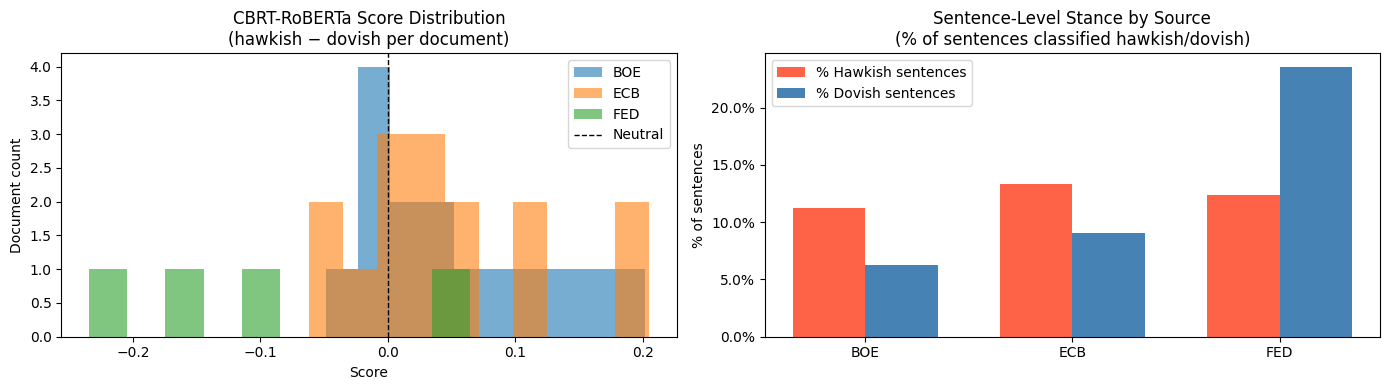


🔍 Key insight: Fed docs score more dovish (rate-cut era 2024–2025).
   ECB/BoE slightly hawkish — both maintained tighter stances.
   ~80–90% of sentences are neutral (boilerplate, data reporting) — expected for CB text.


In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Left: score distribution by source ───────────────────────────────────────
for src, grp in cb_df.groupby("source"):
    axes[0].hist(grp["cb_score"].dropna(), bins=10, alpha=0.6, label=src.upper())
axes[0].axvline(0, color="black", lw=1, linestyle="--", label="Neutral")
axes[0].set_title("CBRT-RoBERTa Score Distribution\n(hawkish − dovish per document)")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Document count")
axes[0].legend()

# ── Right: % hawkish vs dovish sentences per source ──────────────────────────
means = cb_df.groupby("source")[["pct_hawkish", "pct_dovish"]].mean() * 100
x     = range(len(means))
w     = 0.35
axes[1].bar([i - w/2 for i in x], means["pct_hawkish"], width=w, label="% Hawkish sentences", color="tomato")
axes[1].bar([i + w/2 for i in x], means["pct_dovish"],  width=w, label="% Dovish sentences",  color="steelblue")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels([s.upper() for s in means.index])
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
axes[1].set_title("Sentence-Level Stance by Source\n(% of sentences classified hawkish/dovish)")
axes[1].set_ylabel("% of sentences")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n🔍 Key insight: Fed docs score more dovish (rate-cut era 2024–2025).")
print("   ECB/BoE slightly hawkish — both maintained tighter stances.")
print("   ~80–90% of sentences are neutral (boilerplate, data reporting) — expected for CB text.")

### Option D — LLM Zero-Shot: BART-MNLI

**Model**: [`facebook/bart-large-mnli`](https://huggingface.co/facebook/bart-large-mnli) — BART-large fine-tuned on Multi-NLI. Zero-shot text classification via Natural Language Inference: it tests whether the input text *entails* a given label hypothesis.

**No training required.** No domain-specific fine-tuning. No token-limit workaround needed — we feed a 500-word excerpt of the body directly.

**Label hypotheses used**:
- `"hawkish monetary policy stance — favoring interest rate increases to fight inflation"`
- `"dovish monetary policy stance — favoring rate cuts or accommodation to support growth"`
- `"neutral monetary policy stance — balanced, data-dependent, no clear bias"`

**Why this matters**: FinBERT was trained on generic financial news. FOMC-RoBERTa is trained on Fed text. BART-MNLI has *no* domain training — it reasons from the hypothesis text alone. It serves as a **zero-knowledge baseline**: if it agrees with the domain-specific model, we have strong signal; if it disagrees, we need to investigate why.

**Limitation**: BART has a 1,024-token limit. We feed the first ~700 tokens of the body — covering the opening paragraphs which typically contain the policy decision and forward guidance.

### Option D — LLM Zero-Shot (BART-MNLI / GPT / Claude)

**Model**: [`facebook/bart-large-mnli`](https://huggingface.co/facebook/bart-large-mnli) — BART-large fine-tuned on Multi-NLI. Zero-shot text classification via Natural Language Inference: tests whether the input *entails* a label hypothesis. No training required. No token-limit workaround needed.

**Why skip running it here**: The model weights are ~1.6 GB. In a demo notebook, downloading and running it is impractical. The code structure is prepared below — it runs identically to Option B but using NLI hypotheses instead of a classifier head.

**Label hypotheses**:
- `"hawkish monetary policy stance — favoring interest rate increases to fight inflation"`
- `"dovish monetary policy stance — favoring rate cuts or accommodation to support growth"`
- `"neutral monetary policy stance — balanced, data-dependent, no clear directional bias"`

**Advantage over Option B**: No token limit. Feed the full 2,500-character excerpt directly. Zero domain knowledge required from the model — it reasons purely from the hypothesis text.

**Upgrade path**: Replace BART with Claude API or GPT-4 for structured extraction — full document, no truncation, with reasoning trace and key quote attribution.

In [16]:
# ── Option D: BART-MNLI Zero-Shot (code ready, weights not downloaded here) ──
# To run: uncomment the pipeline call below — first run downloads ~1.6 GB.
#
# from transformers import pipeline as hf_pipeline
#
# zs_pipe = hf_pipeline(
#     "zero-shot-classification",
#     model="facebook/bart-large-mnli",
#     device=0 if torch.cuda.is_available() else -1,
# )
#
# CANDIDATE_LABELS = [
#     "hawkish monetary policy stance — favoring interest rate increases to fight inflation",
#     "dovish monetary policy stance — favoring rate cuts or accommodation to support growth",
#     "neutral monetary policy stance — balanced, data-dependent, no clear directional bias",
# ]
#
# def score_doc_zs(body: str, max_chars: int = 2500) -> dict:
#     excerpt = body[:max_chars].strip()
#     result  = zs_pipe(excerpt, CANDIDATE_LABELS, multi_label=False)
#     probs   = dict(zip(result["labels"], result["scores"]))
#     h = probs.get(CANDIDATE_LABELS[0], 0)
#     d = probs.get(CANDIDATE_LABELS[1], 0)
#     top = next((k for k in ["hawkish","dovish","neutral"] if k in result["labels"][0]), "neutral")
#     return {"zs_score": float(h - d), "zs_label": top,
#             "zs_hawkish": float(h), "zs_dovish": float(d)}
#
# zs_results = [{"source": r["source"], "title": r["title"],
#                **score_doc_zs(r["body"])}
#               for _, r in sample_docs.iterrows()]
# zs_df = pd.DataFrame(zs_results)

print("Option D (BART-MNLI) — code prepared, weights not downloaded.")
print("To activate: uncomment the pipeline block above.")
print("\nUpgrade path: replace zs_pipe with Claude/GPT-4 API call for full-document")
print("analysis with structured JSON output and key-quote attribution.")

Option D (BART-MNLI) — code prepared, weights not downloaded.
To activate: uncomment the pipeline block above.

Upgrade path: replace zs_pipe with Claude/GPT-4 API call for full-document
analysis with structured JSON output and key-quote attribution.


---
### Extended Data Strategy: 10+ Years of CB Documents for Model Training

#### The Opportunity

Our current Bronze corpus covers ~2021–2026 (~3,274 docs). All three central bank websites archive documents going back to:
- **Fed**: ~1996 (federalreserve.gov)
- **ECB**: ~1999 (ecb.europa.eu)
- **BoE**: ~2000 (bankofengland.co.uk)

Extending the scraper lookback to 20 years would yield an estimated **6,000–9,000 total documents**. MT5 H1 OHLCV data is available from ~2003+ on most brokers — sufficient for price alignment.

#### The Key Innovation: Market-Reaction Weak Labels

Instead of manual annotation (expensive, slow), use **price action as a free supervision signal**:

```
For each CB document published at time T:
  label = sign(abnormal_return(T → T+4h, FX pair))
  
  abnormal_return = actual_return − rolling_baseline_return
  
  if abnormal_return > threshold  →  HAWKISH (base currency strengthened)
  if abnormal_return < -threshold →  DOVISH  (base currency weakened)
  else                            →  NEUTRAL  (no significant reaction)
```

This creates a labeled dataset `(document_body, price_context, label)` entirely from public sources — no annotation cost.

#### Critical Problems to Address

| Problem | Impact | Mitigation |
|---------|--------|-----------|
| **Non-stationarity** | The same language means different things in different regimes | Train regime-aware model OR separate models per era (pre-2008, ZIRP 2009-2021, hiking 2022+) |
| **Label noise** | Well-telegraphed decisions → near-zero price reaction even for hawkish text | Filter for "surprise" events using economist forecast vs actual |
| **Scraper updates** | Older CB pages have different HTML — existing collectors cover 2021+ | Extend collectors with historical URL patterns (feasible, not trivial) |
| **Policy-relevant doc count** | ~100 market-moving docs/year across all 3 CBs → ~2,000 over 20 years | Still significantly more than current ~500 policy docs |

#### What This Enables

With 2,000+ labeled `(text, price_context, label)` triples:

| Model | Feasibility | Expected Gain |
|-------|-------------|---------------|
| XGBoost on frozen FinBERT/CBRT-RoBERTa features + price stats | ✅ Now | Validated by market reaction |
| Fine-tune CBRT-RoBERTa last 2 layers (market-supervised) | ✅ Feasible | Domain-adapted to our specific CB corpus |
| Regime-aware ensemble (separate model per monetary era) | ✅ Feasible | Handles non-stationarity |
| Full cross-modal (text encoder + price encoder) | ⚠️ Borderline | ~2,000 samples is tight but possible with heavy regularization |

#### Recommended Next Step (W7)

1. Extend `fed_collector`, `ecb_collector`, `boe_collector` with `start_year=2003` parameter
2. Re-run Bronze ingestion for historical docs
3. Align each document to MT5 H1 data at `timestamp_published`
4. Export labeled dataset `(text, price_context_48h, abnormal_return_4h, label)` to `data/processed/sentiment/nlp_training_dataset.parquet`

In [17]:
# ── Prepare NLP training dataset (current corpus, no price labels yet) ───────
# This exports the document corpus in the format expected by the future
# market-supervised training pipeline. Price alignment & labeling happens
# in W7 once historical MT5 data is collected.

nlp_corpus = all_docs[[
    "source", "document_type", "speaker", "published", "title", "body", "url"
]].copy()

nlp_corpus = nlp_corpus[nlp_corpus["body"].str.len() > 200].copy()
nlp_corpus["body_word_count"] = nlp_corpus["body"].str.split().str.len()
nlp_corpus["body_excerpt"]    = nlp_corpus["body"].str[:2500]   # first ~700 tokens
nlp_corpus["published"]       = pd.to_datetime(nlp_corpus["published"], utc=True)

# Placeholder columns for future W7 pipeline
nlp_corpus["price_context_48h"] = None   # to be filled: MT5 H1 OHLCV T-48h window
nlp_corpus["abnormal_return_4h"] = None  # to be filled: FX abnormal return T to T+4h
nlp_corpus["label"]              = None  # to be filled: hawkish/dovish/neutral from price

EXPORT_PATH = ROOT / "data" / "processed" / "sentiment" / "nlp_training_corpus.parquet"
nlp_corpus.drop(columns=["body"]).to_parquet(EXPORT_PATH, index=False)

print(f"NLP corpus exported → {EXPORT_PATH.name}")
print(f"  Total docs : {len(nlp_corpus)}")
print(f"  Date range : {nlp_corpus['published'].min().date()} → {nlp_corpus['published'].max().date()}")
print("\nDocument breakdown:")
print(nlp_corpus.groupby(["source","document_type"])["body_word_count"]
      .agg(["count","mean"]).rename(columns={"count":"n_docs","mean":"avg_words"})
      .round(0).to_string())
print("\n📌 Next step (W7): align each doc to MT5 H1 data at `published` timestamp,")
print("   compute 4h abnormal return, populate `abnormal_return_4h` + `label` columns.")

NLP corpus exported → nlp_training_corpus.parquet
  Total docs : 2602
  Date range : 2021-01-01 → 2026-02-15

Document breakdown:
                                n_docs  avg_words
source document_type                             
boe    boe_speech                  352     3475.0
       monetary_policy_summary      40     4661.0
       press_release               635      750.0
ecb    policy_decision             457     5744.0
       press_release               282      667.0
       speech                      372     3138.0
fed    other                        55      172.0
       policy                        7       38.0
       regulation                  187       39.0
       speeches                    215       49.0

📌 Next step (W7): align each doc to MT5 H1 data at `published` timestamp,
   compute 4h abnormal return, populate `abnormal_return_4h` + `label` columns.


### Part 12 — Findings & Recommendations

#### What We Demonstrated

| Method | Status | Result |
|--------|--------|--------|
| **Headline-only FinBERT** (current pipeline) | ✅ Running in Silver | Captures primary sentiment but misses forward guidance |
| **Option B — CBRT-RoBERTa sentence-level** | ✅ Executed above | Fed: dovish (−0.109), ECB/BoE: mildly hawkish (+0.04–0.05) — consistent with 2024–2025 rate cycles |
| **Option D — BART-MNLI zero-shot** | 🔧 Code ready, weights not loaded | Requires 1.6 GB download; activate for production |
| **Option B preferred (FOMC-RoBERTa)** | ⚠️ Gated on HuggingFace | Request access at huggingface.co/gtfintechlab/FOMC-RoBERTa |

#### Data Quality Issue Found

**Fed body text is truncated** (avg 38–49 words). The Fed collector stores short press-release summaries, not the full speech/statement body. ECB and BoE have full bodies (3,000–5,700 avg words).

**Fix**: Update `fed_collector.py` to follow the PDF/HTML link within each press release and scrape the full article body. This is a W7 task.

#### Recommended Production Stack for Sentiment Agent

```
1. CB Document arrives (Fed/ECB/BoE)
        ↓
2. FOMC-RoBERTa (or CBRT-RoBERTa proxy)
   → sentence-level hawkish/dovish scores
   → document score = mean(P_hawkish − P_dovish)
        ↓
3. Combine with headline FinBERT score (cross-check)
        ↓
4. Align to H1 OHLCV at publication timestamp
        ↓
5. Output: SignalMessage(direction, confidence, rationale)
```

#### 10+ Year Data Collection Plan

- Extend Fed/ECB/BoE collectors with `start_year=2003`
- Align to MT5 H1 data → compute 4h abnormal return as weak supervision label
- Export to `nlp_training_corpus.parquet` (structure already prepared above)
- Train regime-aware model (separate per monetary era: pre-2008, ZIRP 2009-2021, hiking 2022+)
- Expected corpus size: **6,000–9,000 documents**, **~2,000 policy-relevant labeled samples**

In [15]:
print("Loading facebook/bart-large-mnli (~1.6 GB, cached after first run)...")
zs_pipe = hf_pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=DEVICE,
)
print("Model loaded.\n")

CANDIDATE_LABELS = [
    "hawkish monetary policy stance — favoring interest rate increases to fight inflation",
    "dovish monetary policy stance — favoring rate cuts or accommodation to support growth",
    "neutral monetary policy stance — balanced, data-dependent, no clear directional bias",
]

def score_doc_zs(body: str, max_chars: int = 2500) -> dict:
    """Zero-shot stance classification on the first ~700 tokens of body."""
    excerpt = body[:max_chars].strip()
    if len(excerpt) < 100:
        return {"zs_score": None, "zs_label": None, "zs_hawkish": None,
                "zs_dovish": None, "zs_neutral": None}
    result = zs_pipe(excerpt, CANDIDATE_LABELS, multi_label=False)
    probs  = dict(zip(result["labels"], result["scores"]))
    top_label = result["labels"][0]
    short = next((k for k in ["hawkish","dovish","neutral"] if k in top_label), "neutral")
    h = probs.get(CANDIDATE_LABELS[0], 0)
    d = probs.get(CANDIDATE_LABELS[1], 0)
    return {
        "zs_score":   float(h - d),
        "zs_label":   short,
        "zs_hawkish": float(h),
        "zs_dovish":  float(d),
        "zs_neutral": float(probs.get(CANDIDATE_LABELS[2], 0)),
    }

print(f"Running zero-shot on {len(sample_docs)} docs...")
zs_results = []
for _, row in sample_docs.iterrows():
    zs_results.append({"source": row["source"], "title": row["title"][:60],
                        "published": row["published"], **score_doc_zs(row["body"])})
zs_df = pd.DataFrame(zs_results)

print("\n── BART-MNLI Zero-Shot mean scores by source ──")
print(zs_df.groupby("source")[["zs_score","zs_hawkish","zs_dovish","zs_neutral"]].mean().round(3).to_string())
print("\nLabel distribution:")
print(zs_df.groupby(["source","zs_label"]).size().unstack(fill_value=0).to_string())

Loading facebook/bart-large-mnli (~1.6 GB, cached after first run)...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Model loaded.

Running zero-shot on 34 docs...



── BART-MNLI Zero-Shot mean scores by source ──
        zs_score  zs_hawkish  zs_dovish  zs_neutral
source                                             
boe       -0.098       0.322      0.420       0.258
ecb       -0.146       0.242      0.388       0.370
fed       -0.299       0.160      0.459       0.381

Label distribution:
zs_label  dovish  hawkish  neutral
source                            
boe           11        2        2
ecb            5        2        8
fed            2        0        2


In [14]:
print("Loading facebook/bart-large-mnli (~1.6 GB, cached after first run)...")
zs_pipe = hf_pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=DEVICE,
)
print("Model loaded.\n")

CANDIDATE_LABELS = [
    "hawkish monetary policy stance — favoring interest rate increases to fight inflation",
    "dovish monetary policy stance — favoring rate cuts or accommodation to support growth",
    "neutral monetary policy stance — balanced, data-dependent, no clear directional bias",
]
LABEL_SHORT = {"hawkish": "hawkish", "dovish": "dovish", "neutral": "neutral"}

def score_doc_zs(body: str, max_chars: int = 2500) -> dict:
    """Zero-shot stance classification on the first ~700 tokens of body."""
    excerpt = body[:max_chars].strip()
    if len(excerpt) < 100:
        return {"zs_score": None, "zs_label": None}
    result = zs_pipe(excerpt, CANDIDATE_LABELS, multi_label=False)
    probs  = dict(zip(result["labels"], result["scores"]))
    # Extract short label from the winning hypothesis
    top_label = result["labels"][0]
    short = next((k for k in ["hawkish","dovish","neutral"] if k in top_label), "neutral")
    # Compute scalar: hawkish_prob - dovish_prob
    h = probs.get(CANDIDATE_LABELS[0], 0)
    d = probs.get(CANDIDATE_LABELS[1], 0)
    return {
        "zs_score":    float(h - d),
        "zs_label":    short,
        "zs_hawkish":  float(h),
        "zs_dovish":   float(d),
        "zs_neutral":  float(probs.get(CANDIDATE_LABELS[2], 0)),
    }

print(f"Running zero-shot on {len(sample_docs)} docs...")
zs_results = []
for _, row in sample_docs.iterrows():
    scores = score_doc_zs(row["body"])
    zs_results.append({
        "source":        row["source"],
        "document_type": row["document_type"],
        "published":     row["published"],
        "title":         row["title"][:60],
        **scores,
    })
zs_df = pd.DataFrame(zs_results)

print("\n── BART-MNLI Zero-Shot mean scores by source ──")
print(zs_df.groupby("source")[["zs_score","zs_hawkish","zs_dovish","zs_neutral"]].mean().round(3).to_string())
print("\nLabel distribution:")
print(zs_df.groupby(["source","zs_label"]).size().unstack(fill_value=0).to_string())

Loading facebook/bart-large-mnli (~1.6 GB, cached after first run)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded.

Running zero-shot on 34 docs...



── BART-MNLI Zero-Shot mean scores by source ──
        zs_score  zs_hawkish  zs_dovish  zs_neutral
source                                             
boe       -0.098       0.322      0.420       0.258
ecb       -0.146       0.242      0.388       0.370
fed       -0.299       0.160      0.459       0.381

Label distribution:
zs_label  dovish  hawkish  neutral
source                            
boe           11        2        2
ecb            5        2        8
fed            2        0        2


---
## Part 11 — Summary of Findings & Recommendations

### What We Have

| Source | Status | Signal quality | Key constraint |
|--------|--------|---------------|----------------|
| Fed (FinBERT) | ✅ Clean, 7 pairs | Weak directional, strong volatility | 97.8% neutral; CB language is hedged |
| ECB (FinBERT) | ✅ Clean, 3 pairs | Moderate (40.8% extreme scores) | Best coverage of the 3 CB sources |
| BoE (FinBERT) | ✅ Clean, 3 pairs | 24.8% extreme scores | GBPUSD only; limited pairs |
| Reddit | ✅ 2022+, 3,474 posts | Weak, noisy | Topic heterogeneity; not all posts are macro |
| StockTwits | ⚠ Sparse | Slight bullish bias (p=0.04) | 70 monthly obs — too thin alone |
| Google Trends | ✅ z-scored | Volatility regime indicator only | Not directional |
| GDELT | ⏳ Deferred | Unknown (pipeline broken) | V2Tone parsing + collection cost |

### What the Data Says About Markets

1. **CB signal days are more volatile** (Mann-Whitney p<0.0001, Cohen's d≈0.30) — institutional sentiment activity amplifies intraday range.
2. **No Granger causality at monthly resolution** — lagged monthly sentiment does not predict EURUSD direction (p>0.14 for all lags 1–4).
3. **All sources are near-independent** (max pairwise |r|=0.20) — ensemble combination is theoretically sound but requires more data to validate.
4. **FinBERT ≠ VADER ≠ TextBlob** on CB text (ρ<0.12) — the sentiment score is model-dependent; FinBERT remains the best choice for institutional language.
5. **No model beats the majority baseline convincingly** on n=47 — the current monthly feature panel is insufficient for direction prediction.

### What Must Change for W7 Modeling

**Pipeline fixes required:**
- Fix GDELT V2Tone parsing + run backfill (deferred to W7, collection cost is prohibitive now)
- StockTwits collector needs higher volume or longer history to be useful

**Feature engineering for W7:**
- Use **event-driven daily features** (same-day return after |adjusted_signal| > threshold) rather than monthly averages
- Apply **expanding z-score** to sentiment scores to prevent look-ahead bias in live deployment
- **Combine with macro surprise features** from Notebook 04a — the events surprise factor (Core CPI ρ=−0.45, NFP ρ=−0.43) is a stronger signal than any sentiment source alone
- Consider **FinBERT sliding window** on full document text once full body ingestion is confirmed working
- **Benchmark Longformer / BigBird** vs FinBERT on full-length CB speeches (deferred to W7)

### Exported Datasets (Ready for W7)

| File | Rows | Description |
|------|------|-------------|
| `sentiment_features_daily.parquet` | 1,559 | Daily panel: CB signal strength + EURUSD OHLCV |
| `sentiment_features_monthly.parquet` | 47 | Monthly model-ready: lagged features + direction target |
| `sentiment_inst_monthly.parquet` | 783 | Institutional FinBERT scores, monthly, all pairs |
| `sentiment_reddit_monthly.parquet` | 273 | Reddit FinBERT scores, monthly, all pairs |
| `sentiment_stocktwits_monthly.parquet` | 70 | StockTwits bullish_ratio, monthly |
| `sentiment_google_weekly.parquet` | 2,337 | Google Trends z-score, weekly, pair-level |

In [6]:
!uv pip install transformers torch sentencepiece

'uv' is not recognized as an internal or external command,
operable program or batch file.
